# INN Hotels Project

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.

## Importing necessary libraries and data

In [ ]:
# Installing the libraries with the specified version.
#!pip install pandas==1.5.3 numpy==1.25.2 matplotlib==3.7.1 seaborn==0.13.1 scikit-learn==1.2.2 statsmodels==0.14.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library to split data
from sklearn.model_selection import train_test_split
from sklearn import metrics

# To build linear model for statistical analysis and prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV

# To get diferent metric scores
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    make_scorer,
    precision_recall_curve
)

## Data Overview

- Observations
- Sanity checks

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Load cv file and create DataFrame
df = pd.read_csv('/content/drive/MyDrive/Python Course/INNHotelsGroup.csv')

In [ ]:
#Check first 5 rows of DataFrame
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00000,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68000,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00000,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00000,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50000,0,Canceled


In [ ]:
#Check last 5 rows of DataFrame
df.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80000,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95000,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39000,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50000,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67000,0,Not_Canceled


First and last 5 rows show reasonable values for the data frame.

In [ ]:
#Check number of rows and columns in DataFrame
df.shape

(36275, 19)

The dataset contains 36275 rows and 19 columns.

In [ ]:
#Check column data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

***Columns with dtype:***

**Object** - Booking_ID, type_of_meal_plan, room_type_reserved,market_segment_type, booking_status

**int64** - no_of_adults, no_of_children, no_of_weekend_nights, no_of_week_nights, required_car_parking_space, lead_time, arrival_year, arrival_month, arrival_date, repeated_guest, no_of_previous_cancellations, no_of_previous_bookings_not_canceled, no_of_special_requests

**float64** - average_price_per_room

In [ ]:
#Check high level statistics for continuous variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.00000,1.84496,0.51871,0.00000,2.00000,2.00000,2.00000,4.00000
no_of_children,36275.00000,0.10528,0.40265,0.00000,0.00000,0.00000,0.00000,10.00000
no_of_weekend_nights,36275.00000,0.81072,0.87064,0.00000,0.00000,1.00000,2.00000,7.00000
no_of_week_nights,36275.00000,2.20430,1.41090,0.00000,1.00000,2.00000,3.00000,17.00000
required_car_parking_space,36275.00000,0.03099,0.17328,0.00000,0.00000,0.00000,0.00000,1.00000
lead_time,36275.00000,85.23256,85.93082,0.00000,17.00000,57.00000,126.00000,443.00000
arrival_year,36275.00000,2017.82043,0.38384,2017.00000,2018.00000,2018.00000,2018.00000,2018.00000
arrival_month,36275.00000,7.42365,3.06989,1.00000,5.00000,8.00000,10.00000,12.00000
arrival_date,36275.00000,15.59700,8.74045,1.00000,8.00000,16.00000,23.00000,31.00000
repeated_guest,36275.00000,0.02564,0.15805,0.00000,0.00000,0.00000,0.00000,1.00000


**no_of_adults** - Minimum number of 0 adults and maximum of 4 with median of 2 adults. Minimum of 0 adults seems strange and may need to be checked.

**no_of_children** - Minimum number of 0 children with maximum number of 10 children with median of 0 children. first and third quartile also 0 which may need to be investigated.

**no_of_weekend_nights** - Minimum number of 0 weekend nights and maximum of 7 with a median of 1 night.

**no_of_weeknights** - Minimum number of week nights is zero and maximum of 17 with a median of 2 week nights.

**required_car_parking_space** - Minimum number of car spaces is 0 and maximum 1 with a median of 0. First and third quartiles also 0 which may need to be checked.

**lead_time** - Minimum lead time of 0 with maximum lead time of 443 days with median of 57 days.

**arrival_year** - Minimum arrival year of 2017 and maximum arrival year of 2018 with median as 2018. Implying all dats are from 2017 to 2018. May consider making this a catagorical variable rather than an int.

**arrival_month** - Minimum arrival month in January with maximum in December with the median arribval month being in August. May also consider making this a catagorical variable rather than int.

**arrival_date** - Minimum arrival date of the 1st of the moonth and last being the 31st of the month with the median being the 16th. May also consider making this a catagorical variable.

**repeated_guest** - Boolean value of 1 or 0. May consider making this catagorical. Median guest is not a repeat guest.

**no_of_previous_cancellations** - Minimum cancellation of 0 and maximum of 13 cancellations previously. First and third quartiles also 0 which may need to be looked into more.

**no_of_previous_bookings_not_cancelled** - Minimum of 0 bookings not cancelled and maximum of 58 not cancelled with a median first and third quartile of 0. Need to check the relationship of this with repeated guests.

**avg_price_per_room** - Minimum price of 0 and maximum of 540 with a median price of 99.45. Need to check price of zero to see if it makes sense in the data.

**no_of_special_requests** - Minimum of 0 special requests and maximum of 5 with a median of 0.

In [ ]:
#Check for any null values in DataFrame
df.isna().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


There are no null values in the dataset.

In [ ]:
#Check for any duplictaed rows in DataFrame
df.duplicated().sum()

np.int64(0)

There are no duplicated rows in the dataset.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**:
1. What are the busiest months in the hotel? [Answer](#scrollTo=zDBFvKmjFTJ4&line=1&uniqifier=1)
2. Which market segment do most of the guests come from? [Answer](#scrollTo=5Zod3FT2CEaM&line=1&uniqifier=1)
3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments? [Answer](#scrollTo=PeicvxOo8xFI&line=9&uniqifier=1)
4. What percentage of bookings are canceled? [Answer](#scrollTo=kOdF6ZxiDAh1&line=3&uniqifier=1)
5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel? [Answer](#scrollTo=C4q7hbxbCwqT&line=3&uniqifier=1)
6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation? [Answer](#scrollTo=plcUlErqTXMr&line=5&uniqifier=1)

###Univariate Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

#### Catagorical variables

In [ ]:
#Create function to make count plot and value count table for all catagorical variables
def uni_analy_cat(col, ord_desc=True):
  if ord_desc:
    descending_order = df[col].value_counts().index

    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col, order=descending_order)
    plt.show()
    print(df[col].value_counts())
  else:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=col)
    plt.show()
    print(df[col].value_counts())

In [ ]:
#List all Categorical variables for reference
df.select_dtypes(include='object').columns

Index(['Booking_ID', 'type_of_meal_plan', 'room_type_reserved',
       'market_segment_type', 'booking_status'],
      dtype='object')

In [ ]:
#Check number of unique data points for each catagorical variable
df.select_dtypes(include='object').nunique()

,0
Booking_ID,36275
type_of_meal_plan,4
room_type_reserved,7
market_segment_type,5
booking_status,2


Booking ID has the same number of unique data points as rows in the dataset, indicating each Booking ID is unique for the entire dataframe.

All other catagorical variables have 2-7 unique variables and can be plotted.

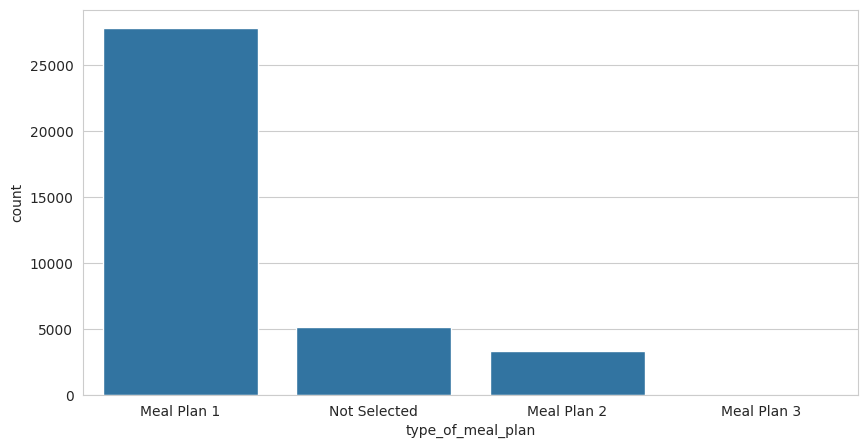

type_of_meal_plan
Meal Plan 1     27835
Not Selected     5130
Meal Plan 2      3305
Meal Plan 3         5
Name: count, dtype: int64


In [ ]:
#Count plot for type_of_meal plan
uni_analy_cat('type_of_meal_plan')

Meal plan 1 is the most popular choice by far with 7,835 with Not Selected second most popular with 5130.

Meal plan 2 has 3305 and meal plan 3 only has 5.

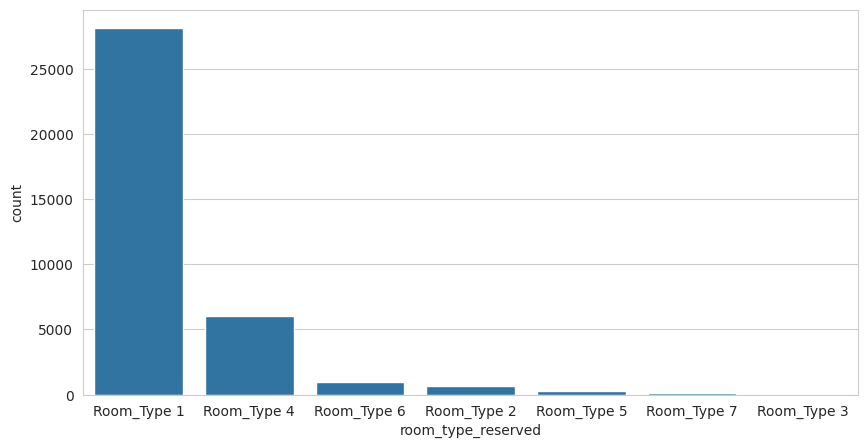

room_type_reserved
Room_Type 1    28130
Room_Type 4     6057
Room_Type 6      966
Room_Type 2      692
Room_Type 5      265
Room_Type 7      158
Room_Type 3        7
Name: count, dtype: int64


In [ ]:
#Count plot for type_of_room type reserved
uni_analy_cat('room_type_reserved')

Room type 1 is the most popular choice with 28,130 followed by room type 4 with 6057.

All other room types have values less than 100 with room type 6 with 966, type 2 with 692, type 5 with 265, type 7 with 158, type 3 with 7.

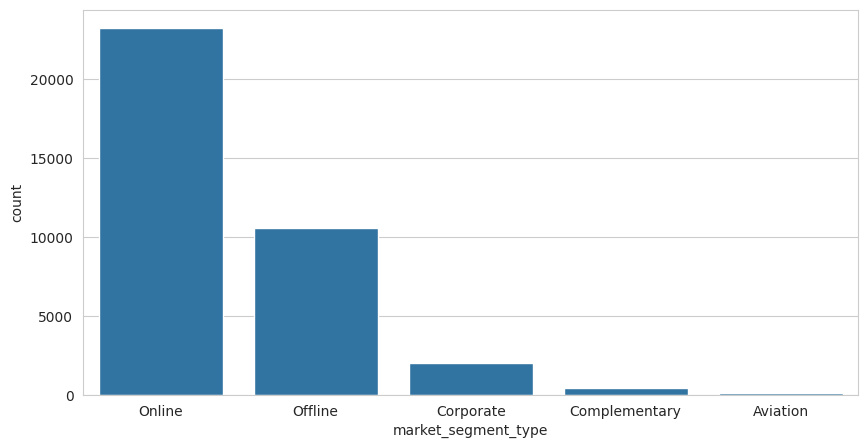

market_segment_type
Online           23214
Offline          10528
Corporate         2017
Complementary      391
Aviation           125
Name: count, dtype: int64


In [ ]:
#Count plot for market segment type
uni_analy_cat('market_segment_type')

Online is the most popular market segment with 23,214 (answering question 2 of the [list of leading questions](#scrollTo=classified-traveler)) followed by offline with 10528.

Corporate has 2017 and Complementary and aviation with only 391 and 125 respectively.

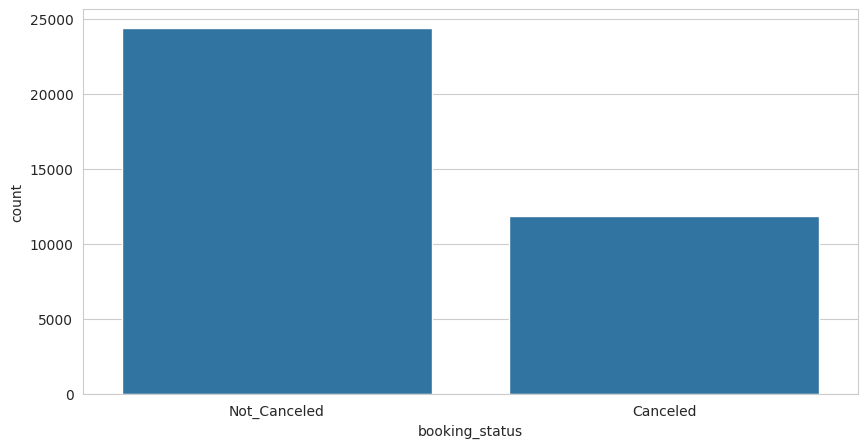

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64


In [ ]:
#Count plot for booking status
uni_analy_cat('booking_status')

In [ ]:
perc_cancel = round((11885 / (24390+11885)) * 100, 2)

print(f'The percentage of cancelled bookings is {perc_cancel}%')

The percentage of cancelled bookings is 32.76%


The majority of guests have not cancelled (24,390).

32.76% of guests have cancelled their bookings. This answers question 4 of the [leading questions list](#scrollTo=classified-traveler).

In [ ]:
#Convert the arrival_year, month, date, repeated guest and required car parking space to catagorical variables
df['arrival_year'] = df['arrival_year'].astype('object')
df['arrival_month'] = df['arrival_month'].astype('object')
df['arrival_date'] = df['arrival_date'].astype('object')
df['repeated_guest'] = df['repeated_guest'].map({0:'No', 1:'Yes'})
df['required_car_parking_space'] = df['required_car_parking_space'].map({0:'No', 1:'Yes'})

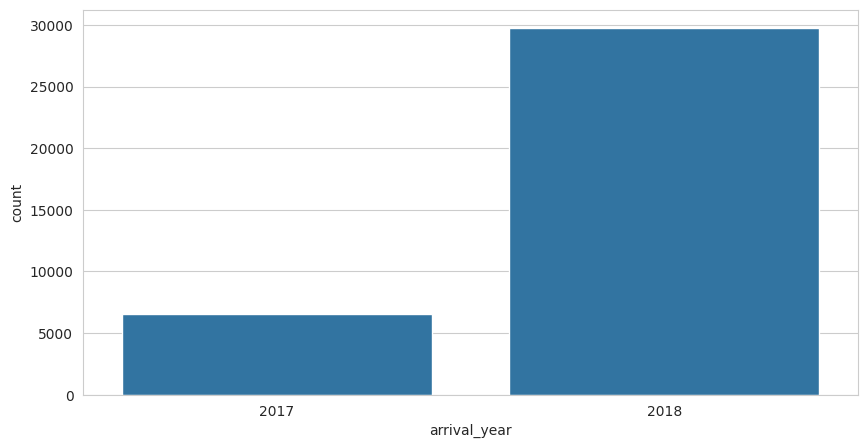

arrival_year
2018    29761
2017     6514
Name: count, dtype: int64


In [ ]:
#Count plot for arrival year
uni_analy_cat('arrival_year', False)

2018 is the most popular arrival year for the dataset with 29,761 arrivals.

2017 has 6514 arrivals.

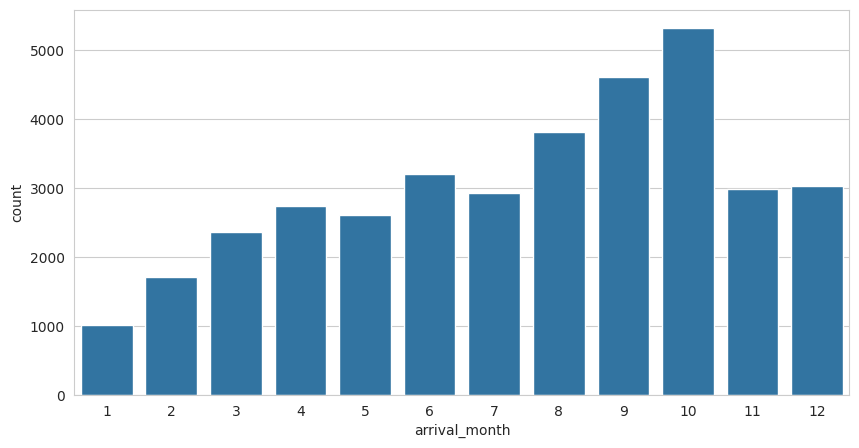

arrival_month
10    5317
9     4611
8     3813
6     3203
12    3021
11    2980
7     2920
4     2736
5     2598
3     2358
2     1704
1     1014
Name: count, dtype: int64


In [ ]:
#Count plot for arrival month
uni_analy_cat('arrival_month', False)

End of Summer early fall months (August-October) are the most popular arrival months with waning arrivals in the colder months. This answers question 1 from the [list of leading questions](#scrollTo=classified-traveler).

Starting in January as the year progresses and weather becomes warmer, arrivals increase until November and December.

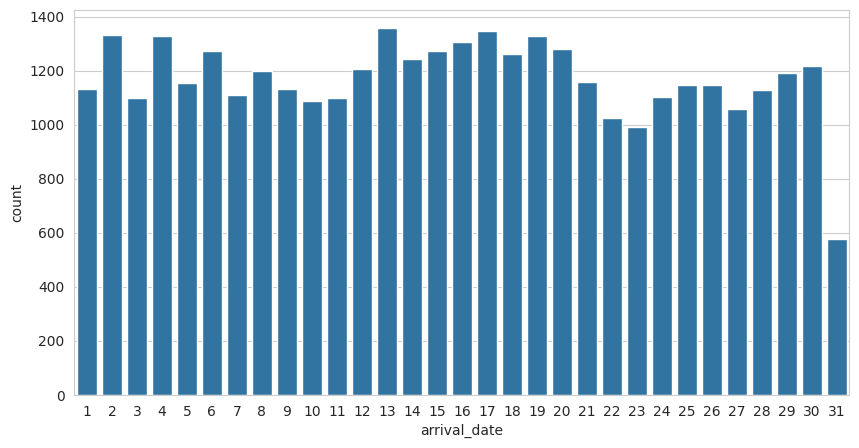

arrival_date
13    1358
17    1345
2     1331
19    1327
4     1327
16    1306
20    1281
6     1273
15    1273
18    1260
14    1242
30    1216
12    1204
8     1198
29    1190
21    1158
5     1154
25    1146
26    1146
1     1133
9     1130
28    1129
7     1110
24    1103
3     1098
11    1098
10    1089
27    1059
22    1023
23     990
31     578
Name: count, dtype: int64


In [ ]:
#Count plot for arrival date
uni_analy_cat('arrival_date', False)

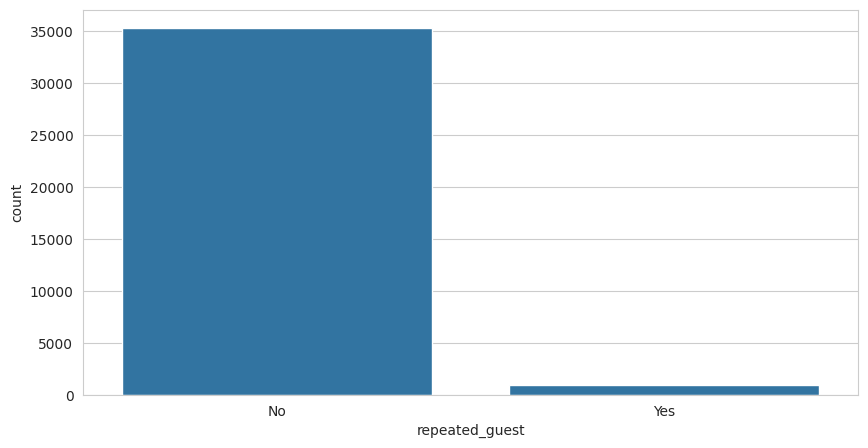

repeated_guest
No     35345
Yes      930
Name: count, dtype: int64


In [ ]:
#Count plot for arrival date
uni_analy_cat('repeated_guest')

Generally, arrival dates are mostly uniform with the middle of the month dates having slightly higher arrivals than the beginning and end of the month.

The 31st has the fewest number of arrivals since it is not a date for all months in the year.

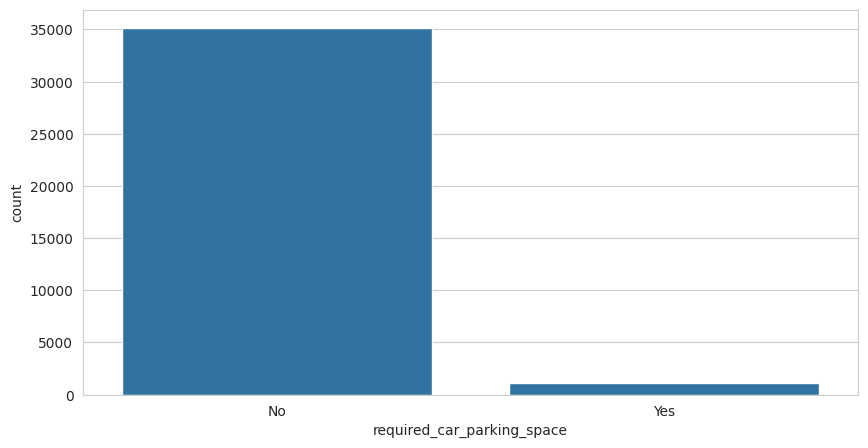

required_car_parking_space
No     35151
Yes     1124
Name: count, dtype: int64


In [ ]:
#Count plot for required car parking space
uni_analy_cat('required_car_parking_space')

The vast majority of guests do not require a parking space (35,151) while a small amount do (1124).

####Continuous Variables

In [ ]:
#Create function to create same plots for all continuous variables
def uni_analy_cont(col):
  plt.figure(figsize=(10,5))
  sns.histplot(data=df, x=col, kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()
  plt.figure(figsize=(10,5))
  sns.boxplot(data=df, x=col)
  plt.title(f'Boxplot of {col}')
  plt.show()
  print(df[col].describe())

In [ ]:
#Make list of all continuous variables
df.select_dtypes(include='number').columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'lead_time', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests'],
      dtype='object')



no_of_adults




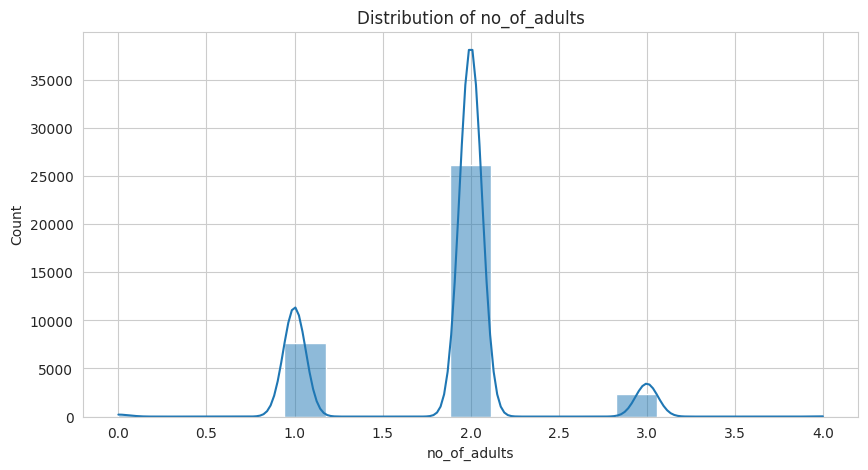

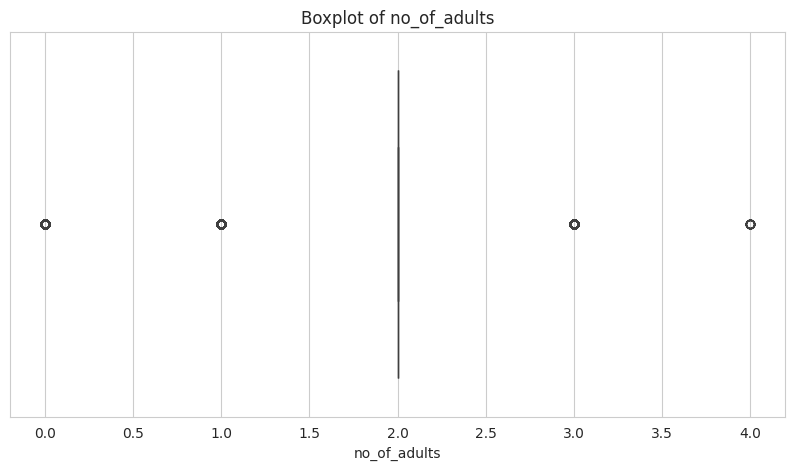

count   36275.00000
mean        1.84496
std         0.51871
min         0.00000
25%         2.00000
50%         2.00000
75%         2.00000
max         4.00000
Name: no_of_adults, dtype: float64


---------------------------------------------------------------------------------------------------------------------------




no_of_children




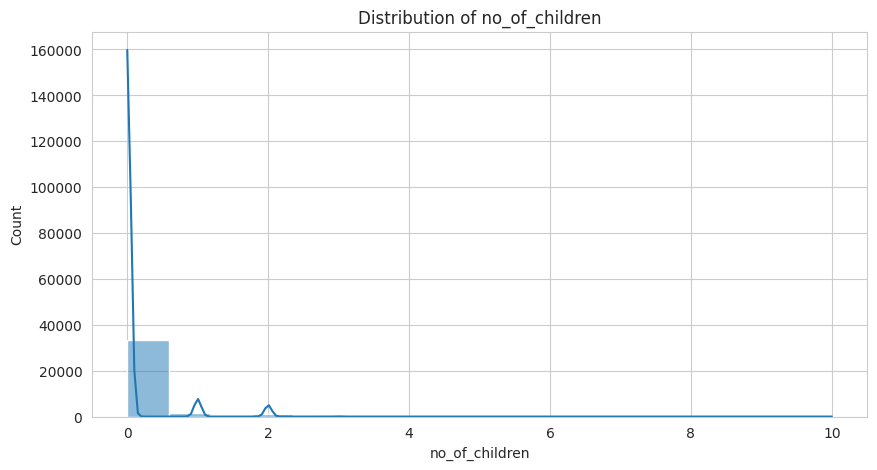

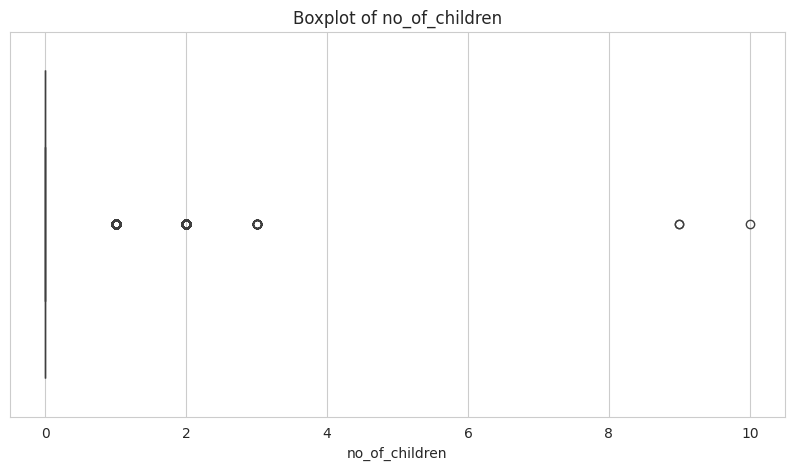

count   36275.00000
mean        0.10528
std         0.40265
min         0.00000
25%         0.00000
50%         0.00000
75%         0.00000
max        10.00000
Name: no_of_children, dtype: float64


---------------------------------------------------------------------------------------------------------------------------




no_of_weekend_nights




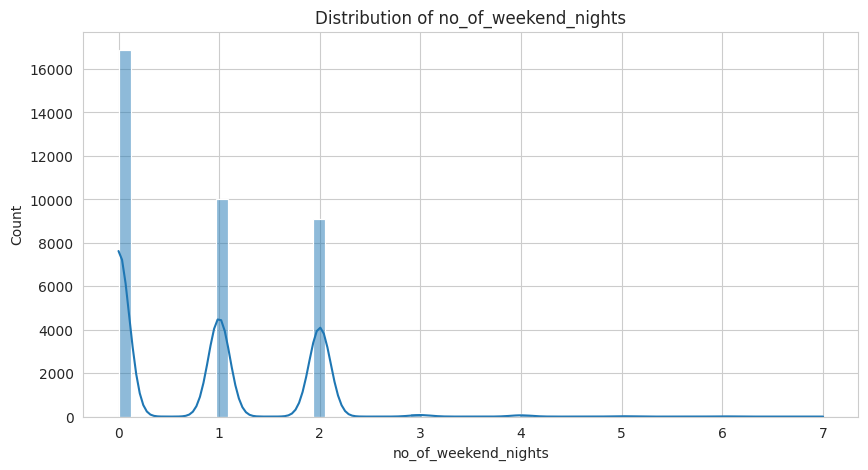

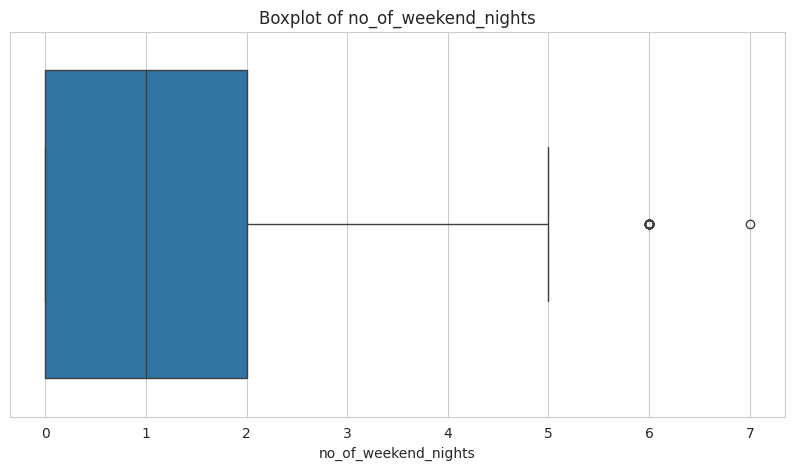

count   36275.00000
mean        0.81072
std         0.87064
min         0.00000
25%         0.00000
50%         1.00000
75%         2.00000
max         7.00000
Name: no_of_weekend_nights, dtype: float64


---------------------------------------------------------------------------------------------------------------------------




no_of_week_nights




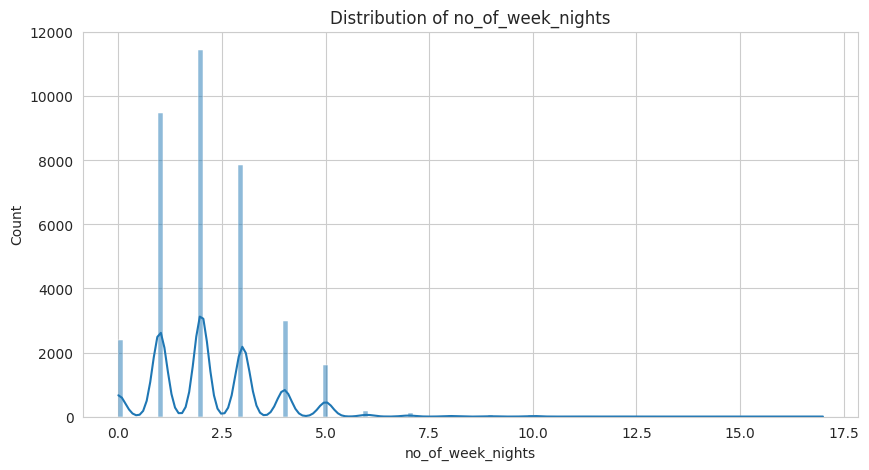

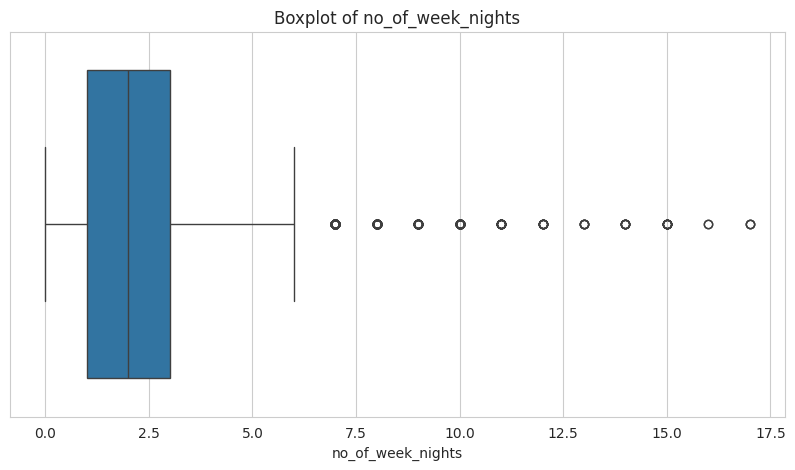

count   36275.00000
mean        2.20430
std         1.41090
min         0.00000
25%         1.00000
50%         2.00000
75%         3.00000
max        17.00000
Name: no_of_week_nights, dtype: float64


---------------------------------------------------------------------------------------------------------------------------




lead_time




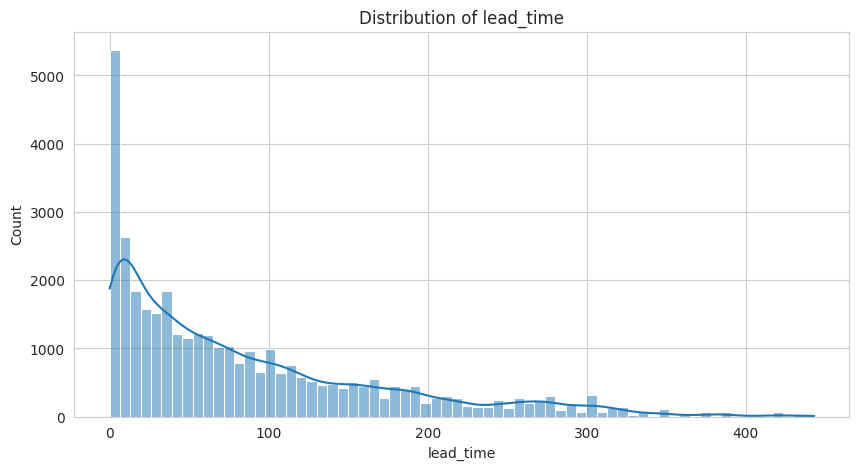

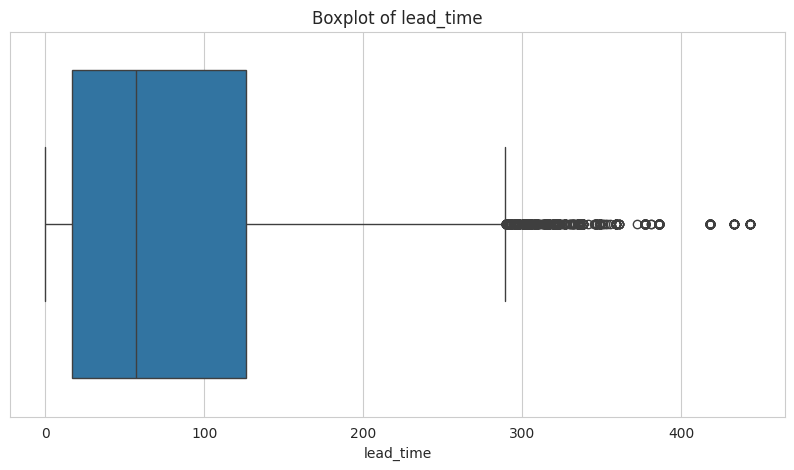

count   36275.00000
mean       85.23256
std        85.93082
min         0.00000
25%        17.00000
50%        57.00000
75%       126.00000
max       443.00000
Name: lead_time, dtype: float64


---------------------------------------------------------------------------------------------------------------------------




no_of_previous_cancellations




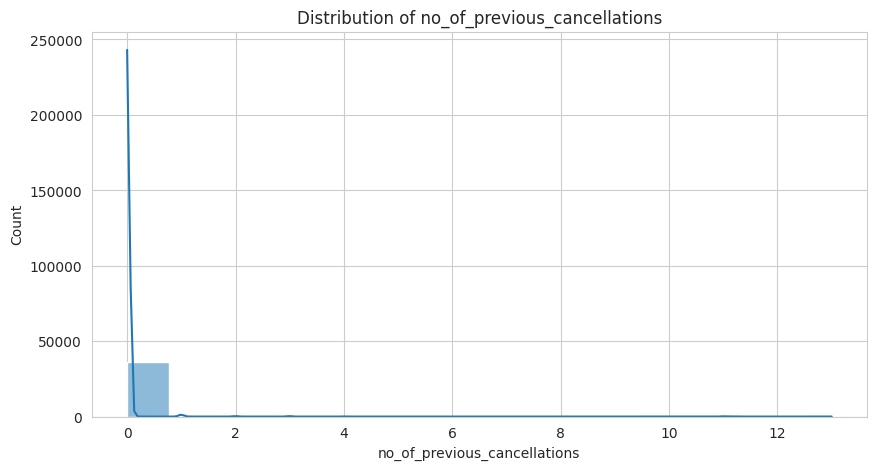

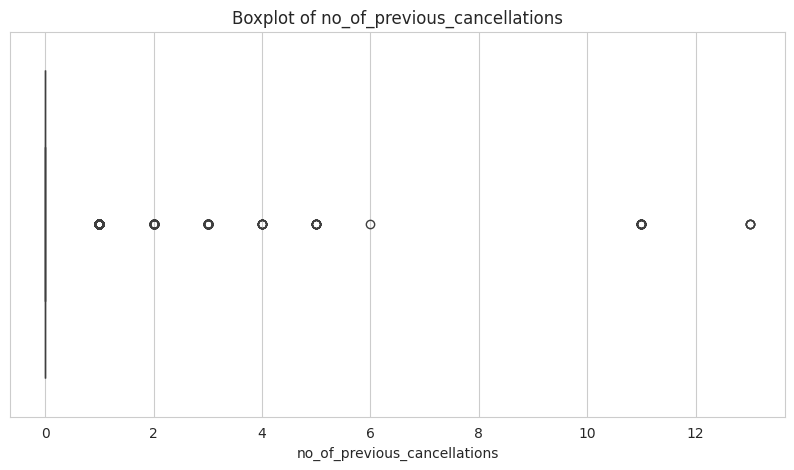

count   36275.00000
mean        0.02335
std         0.36833
min         0.00000
25%         0.00000
50%         0.00000
75%         0.00000
max        13.00000
Name: no_of_previous_cancellations, dtype: float64


---------------------------------------------------------------------------------------------------------------------------




no_of_previous_bookings_not_canceled




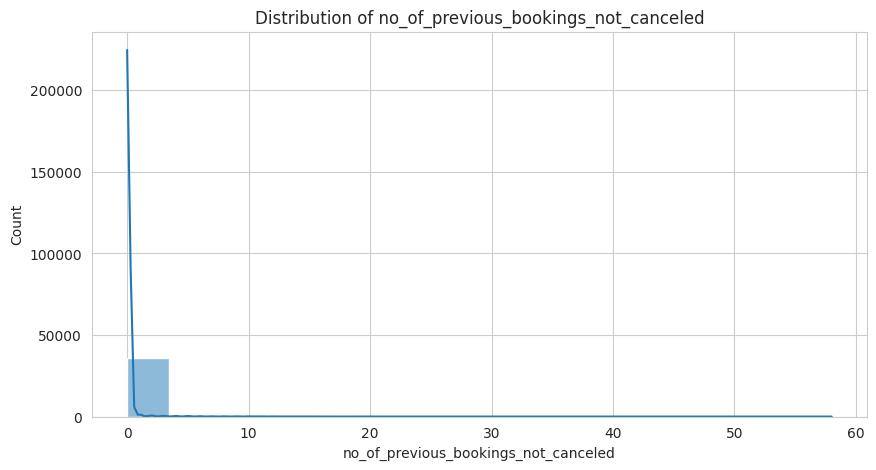

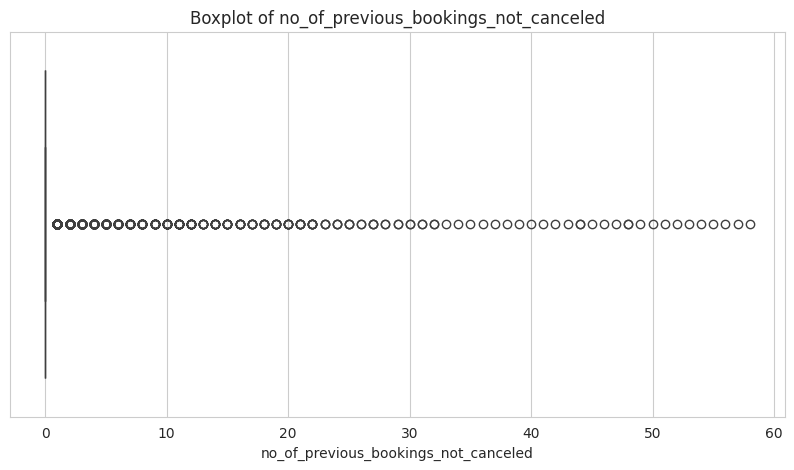

count   36275.00000
mean        0.15341
std         1.75417
min         0.00000
25%         0.00000
50%         0.00000
75%         0.00000
max        58.00000
Name: no_of_previous_bookings_not_canceled, dtype: float64


---------------------------------------------------------------------------------------------------------------------------




avg_price_per_room




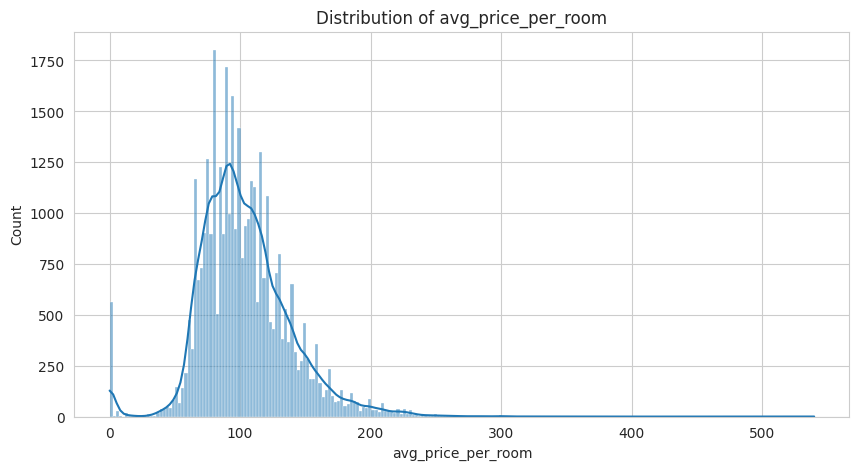

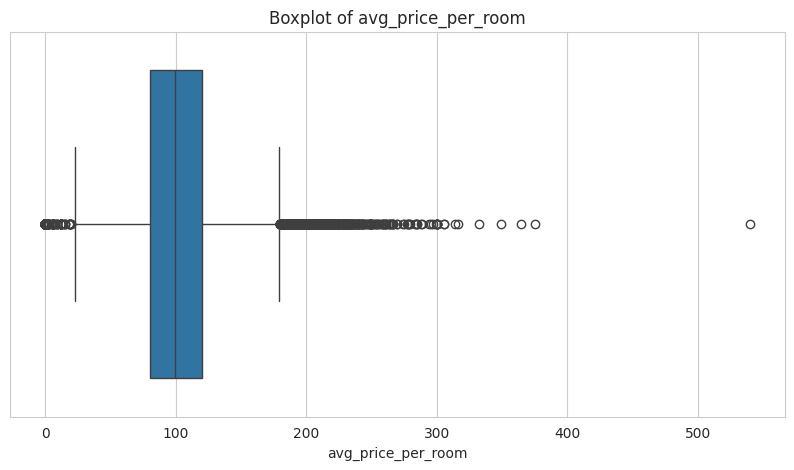

count   36275.00000
mean      103.42354
std        35.08942
min         0.00000
25%        80.30000
50%        99.45000
75%       120.00000
max       540.00000
Name: avg_price_per_room, dtype: float64


---------------------------------------------------------------------------------------------------------------------------




no_of_special_requests




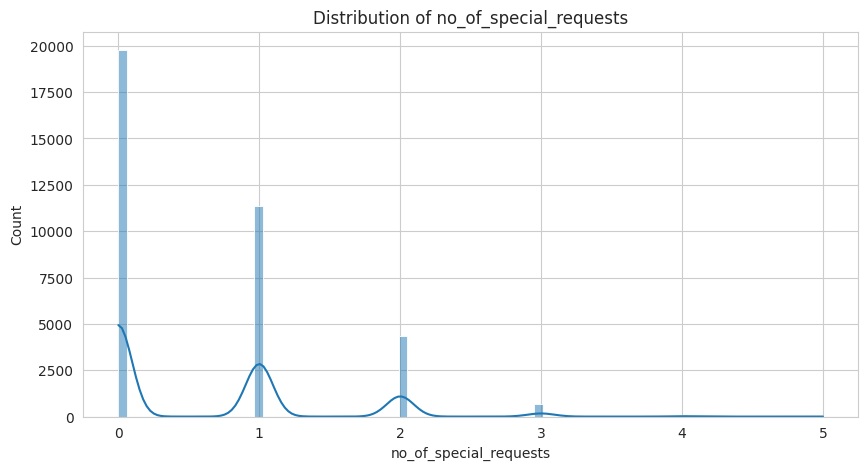

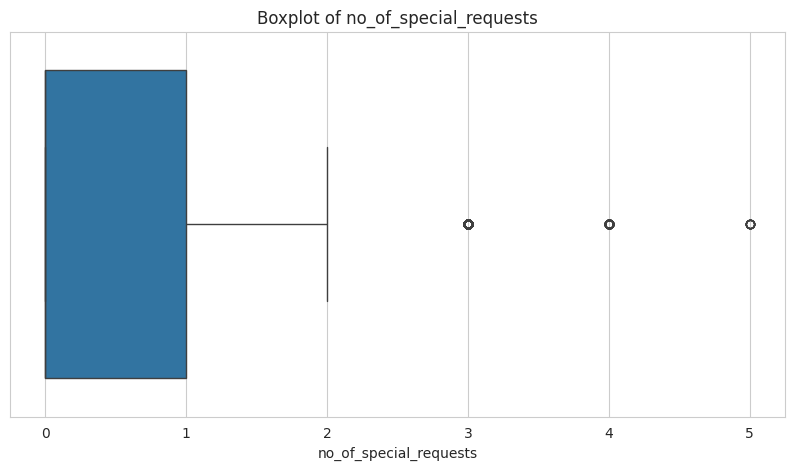

count   36275.00000
mean        0.61966
std         0.78624
min         0.00000
25%         0.00000
50%         0.00000
75%         1.00000
max         5.00000
Name: no_of_special_requests, dtype: float64


---------------------------------------------------------------------------------------------------------------------------




In [ ]:
#Run uni_anal_cont function for all continuous variables
for col in df.select_dtypes(include='number').columns:
  print(f'\n\n\033[1m{col}\033[0m\n\n')
  uni_analy_cont(col)
  print('\n\n---------------------------------------------------------------------------------------------------------------------------\n\n')

Univariate analysis of continuous variables is in line with findings from high level analysis from the [high level data overview](#scrollTo=1aJVwgFk3Ffm&line=27&uniqifier=1)  section.

All continuous variables with exception of number of adults are right skewed

###Bivariate Analysis

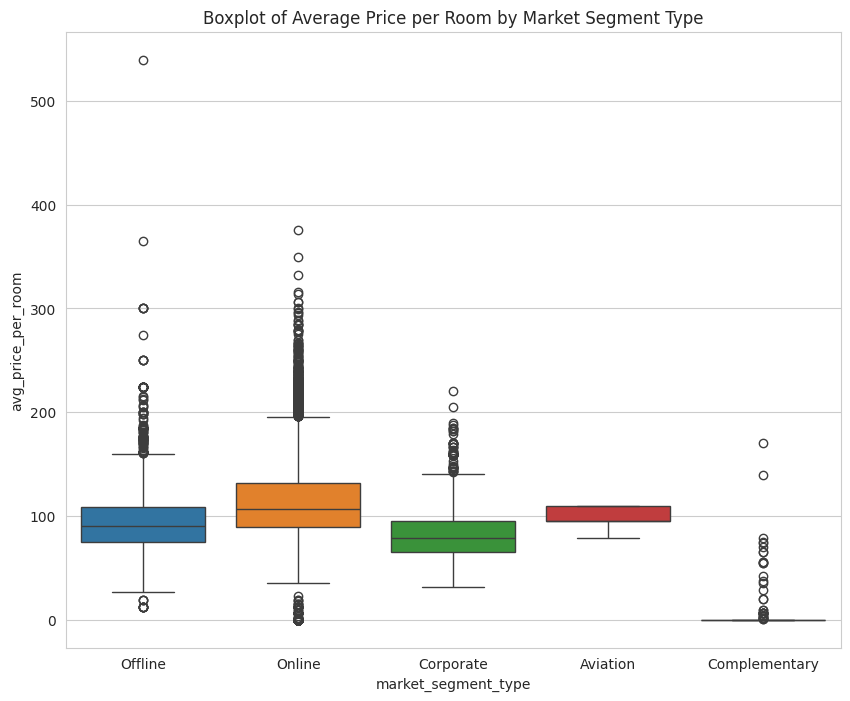

In [ ]:
#Make boxplot comparing market_segment_type and average price per room
plt.figure(figsize=(10,8))
sns.boxplot(data=df, x='market_segment_type', y='avg_price_per_room', hue='market_segment_type')
plt.title('Boxplot of Average Price per Room by Market Segment Type')
plt.show()

Online room pricing has the highest median price of around 100 Euros.

Offline and aviation with a median price around 90 Euros, but offline having more variance between Q1, Q2, and Q3. Offline has the largest outlier value of around 575 Euros.

Corporate pricing has a median price around 85 Euros.

Complementary has a median price around 0 with some outliers as high as 150 Euros.

This provides an answer to question 3 in the [list of leading questions](#scrollTo=classified-traveler).

The percentage of non-cancelled bookings for repeated guests is 98.28%
The percentage of cancelled bookings for repeated guests is 1.72%


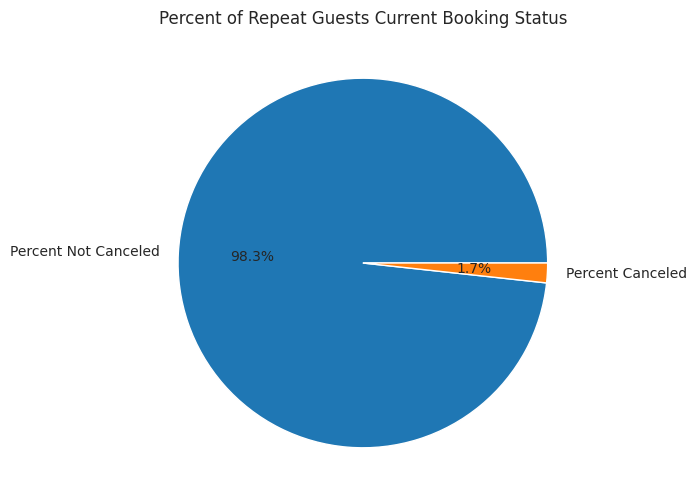

In [ ]:
#Check percentage of Repeat guests current booking status

perc_non_cancel = (df[df['repeated_guest'] == 'Yes'].value_counts('booking_status')[0] / df[df['repeated_guest'] == 'Yes'].value_counts('booking_status').sum()) * 100
perc_cancel = (df[df['repeated_guest'] == 'Yes'].value_counts('booking_status')[1] / df[df['repeated_guest'] == 'Yes'].value_counts('booking_status').sum()) * 100

print(f'The percentage of non-cancelled bookings for repeated guests is {round(perc_non_cancel, 2)}%')
print(f'The percentage of cancelled bookings for repeated guests is {round(perc_cancel, 2)}%')

data = {'labels': ['Percent Not Canceled', 'Percent Canceled'],
        'values': [perc_non_cancel, perc_cancel]}
df_temp = pd.DataFrame(data)

sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
plt.pie(df_temp['values'], labels=df_temp['labels'], autopct='%1.1f%%')
plt.title('Percent of Repeat Guests Current Booking Status')
plt.show()

Total number of repeat guests is 930
Number of repeat guests where current booking is cancelled or they have cancelled in the past is 338
Percentage of repeat guests where current booking is cancelled or they have cancelled in the past is 36%


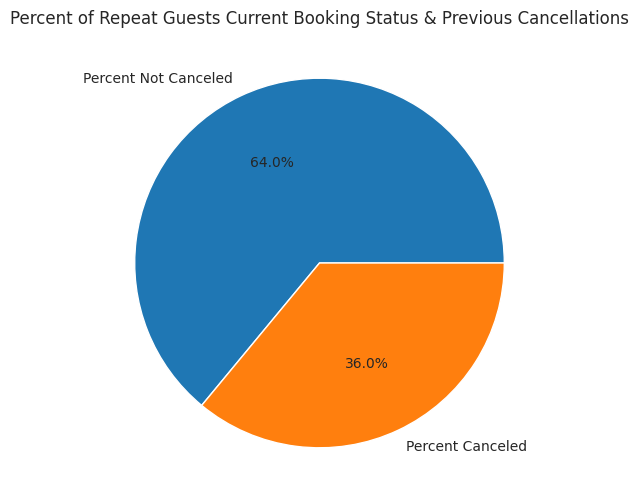

In [ ]:
#Check percentage of Repeat guests current booking status or previous cancellations
df_temp = df[df['repeated_guest'] == 'Yes']

num_cancel = 0

total_repeat_guest = df_temp.shape[0]

print('Total number of repeat guests is', total_repeat_guest)

df_temp['booking_status'].value_counts()

num_cancel += df_temp['booking_status'].value_counts()[1]

df_temp2 = df_temp[df_temp['booking_status'] == 'Not_Canceled']

df_temp2[df_temp2['no_of_previous_cancellations'] > 0].value_counts('no_of_previous_cancellations').sum()

num_cancel += df_temp2[df_temp2['no_of_previous_cancellations'] > 0].value_counts('no_of_previous_cancellations').sum()

print('Number of repeat guests where current booking is cancelled or they have cancelled in the past is',num_cancel)

print(f'Percentage of repeat guests where current booking is cancelled or they have cancelled in the past is {round((num_cancel / total_repeat_guest) * 100)}%')

data = {'labels': ['Percent Not Canceled', 'Percent Canceled'],
        'values': [100 - round((num_cancel / total_repeat_guest) * 100), round((num_cancel / total_repeat_guest) * 100)]}
df_temp = pd.DataFrame(data)

sns.set_style("whitegrid")
plt.figure(figsize=(10,6))
plt.pie(df_temp['values'], labels=df_temp['labels'], autopct='%1.1f%%')
plt.title('Percent of Repeat Guests Current Booking Status & Previous Cancellations')
plt.show()

Of repeat customers, 98.3 percent do not cancel their current bookings while only 1.7% do cancel.

Looking at all cancellations for the current booking and past bookings, 36% of repeat customers have cancelled before.

This answers question 5 of the [list of leading questions](#scrollTo=classified-traveler&line=5&uniqifier=1).

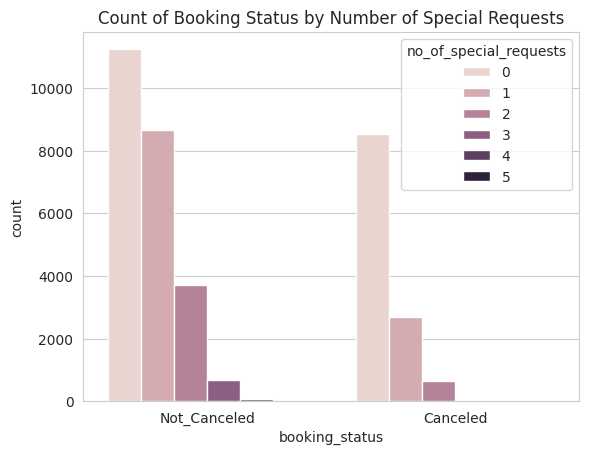

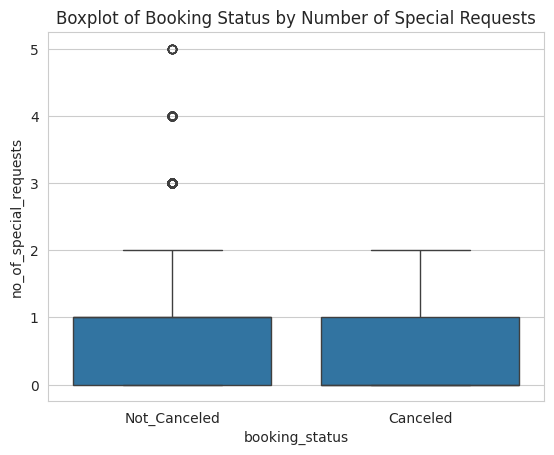

In [ ]:
#Check count of not cancelled and cancelled booking status with number of special requests
sns.countplot(data=df, x='booking_status', hue='no_of_special_requests')
plt.title('Count of Booking Status by Number of Special Requests')
plt.show()
sns.boxplot(data=df, x='booking_status', y='no_of_special_requests')
plt.title('Boxplot of Booking Status by Number of Special Requests')
plt.show()

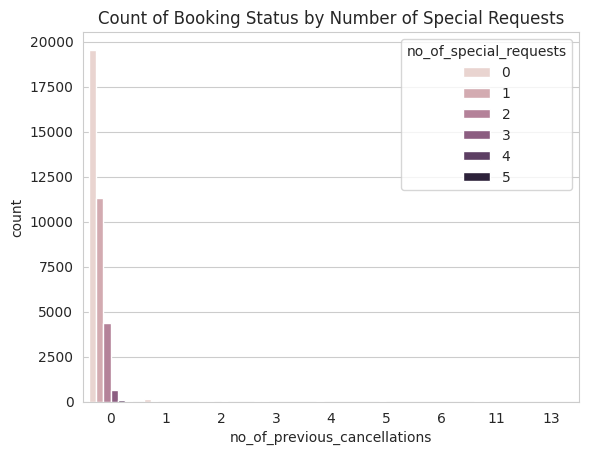

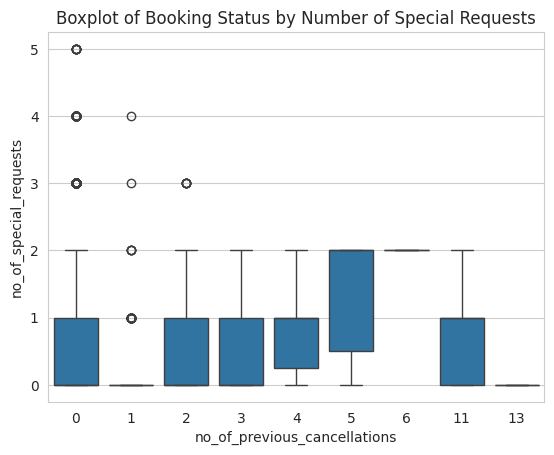

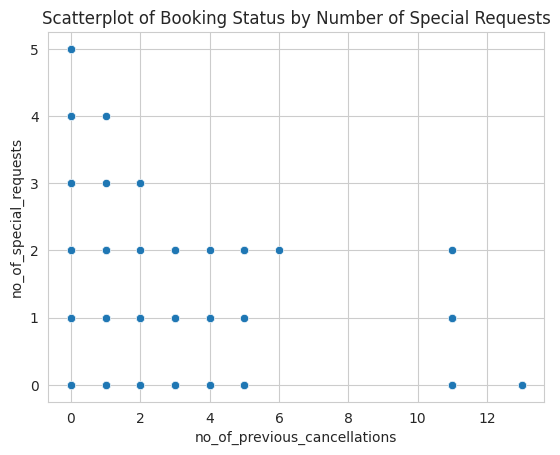

In [ ]:
#Check count of not cancelled and cancelled booking status with number of special requests
sns.countplot(data=df, x='no_of_previous_cancellations', hue='no_of_special_requests')
plt.title('Count of Booking Status by Number of Special Requests')
plt.show()
sns.boxplot(data=df, x='no_of_previous_cancellations', y='no_of_special_requests')
plt.title('Boxplot of Booking Status by Number of Special Requests')
plt.show()
sns.scatterplot(data=df, x='no_of_previous_cancellations', y='no_of_special_requests')
plt.title('Scatterplot of Booking Status by Number of Special Requests')
plt.show()


Based on surface level analysis of number of previous cancellations and booking status cancellations with number of special requests, there is no strong evidence suggesting more special requests result in more cancellations.

The opposite is true as well that no special requests doesn't necessarily point to a guest cancelling.

This answers question 6 of the [list of leading questions](#scrollTo=classified-traveler&line=6&uniqifier=1).

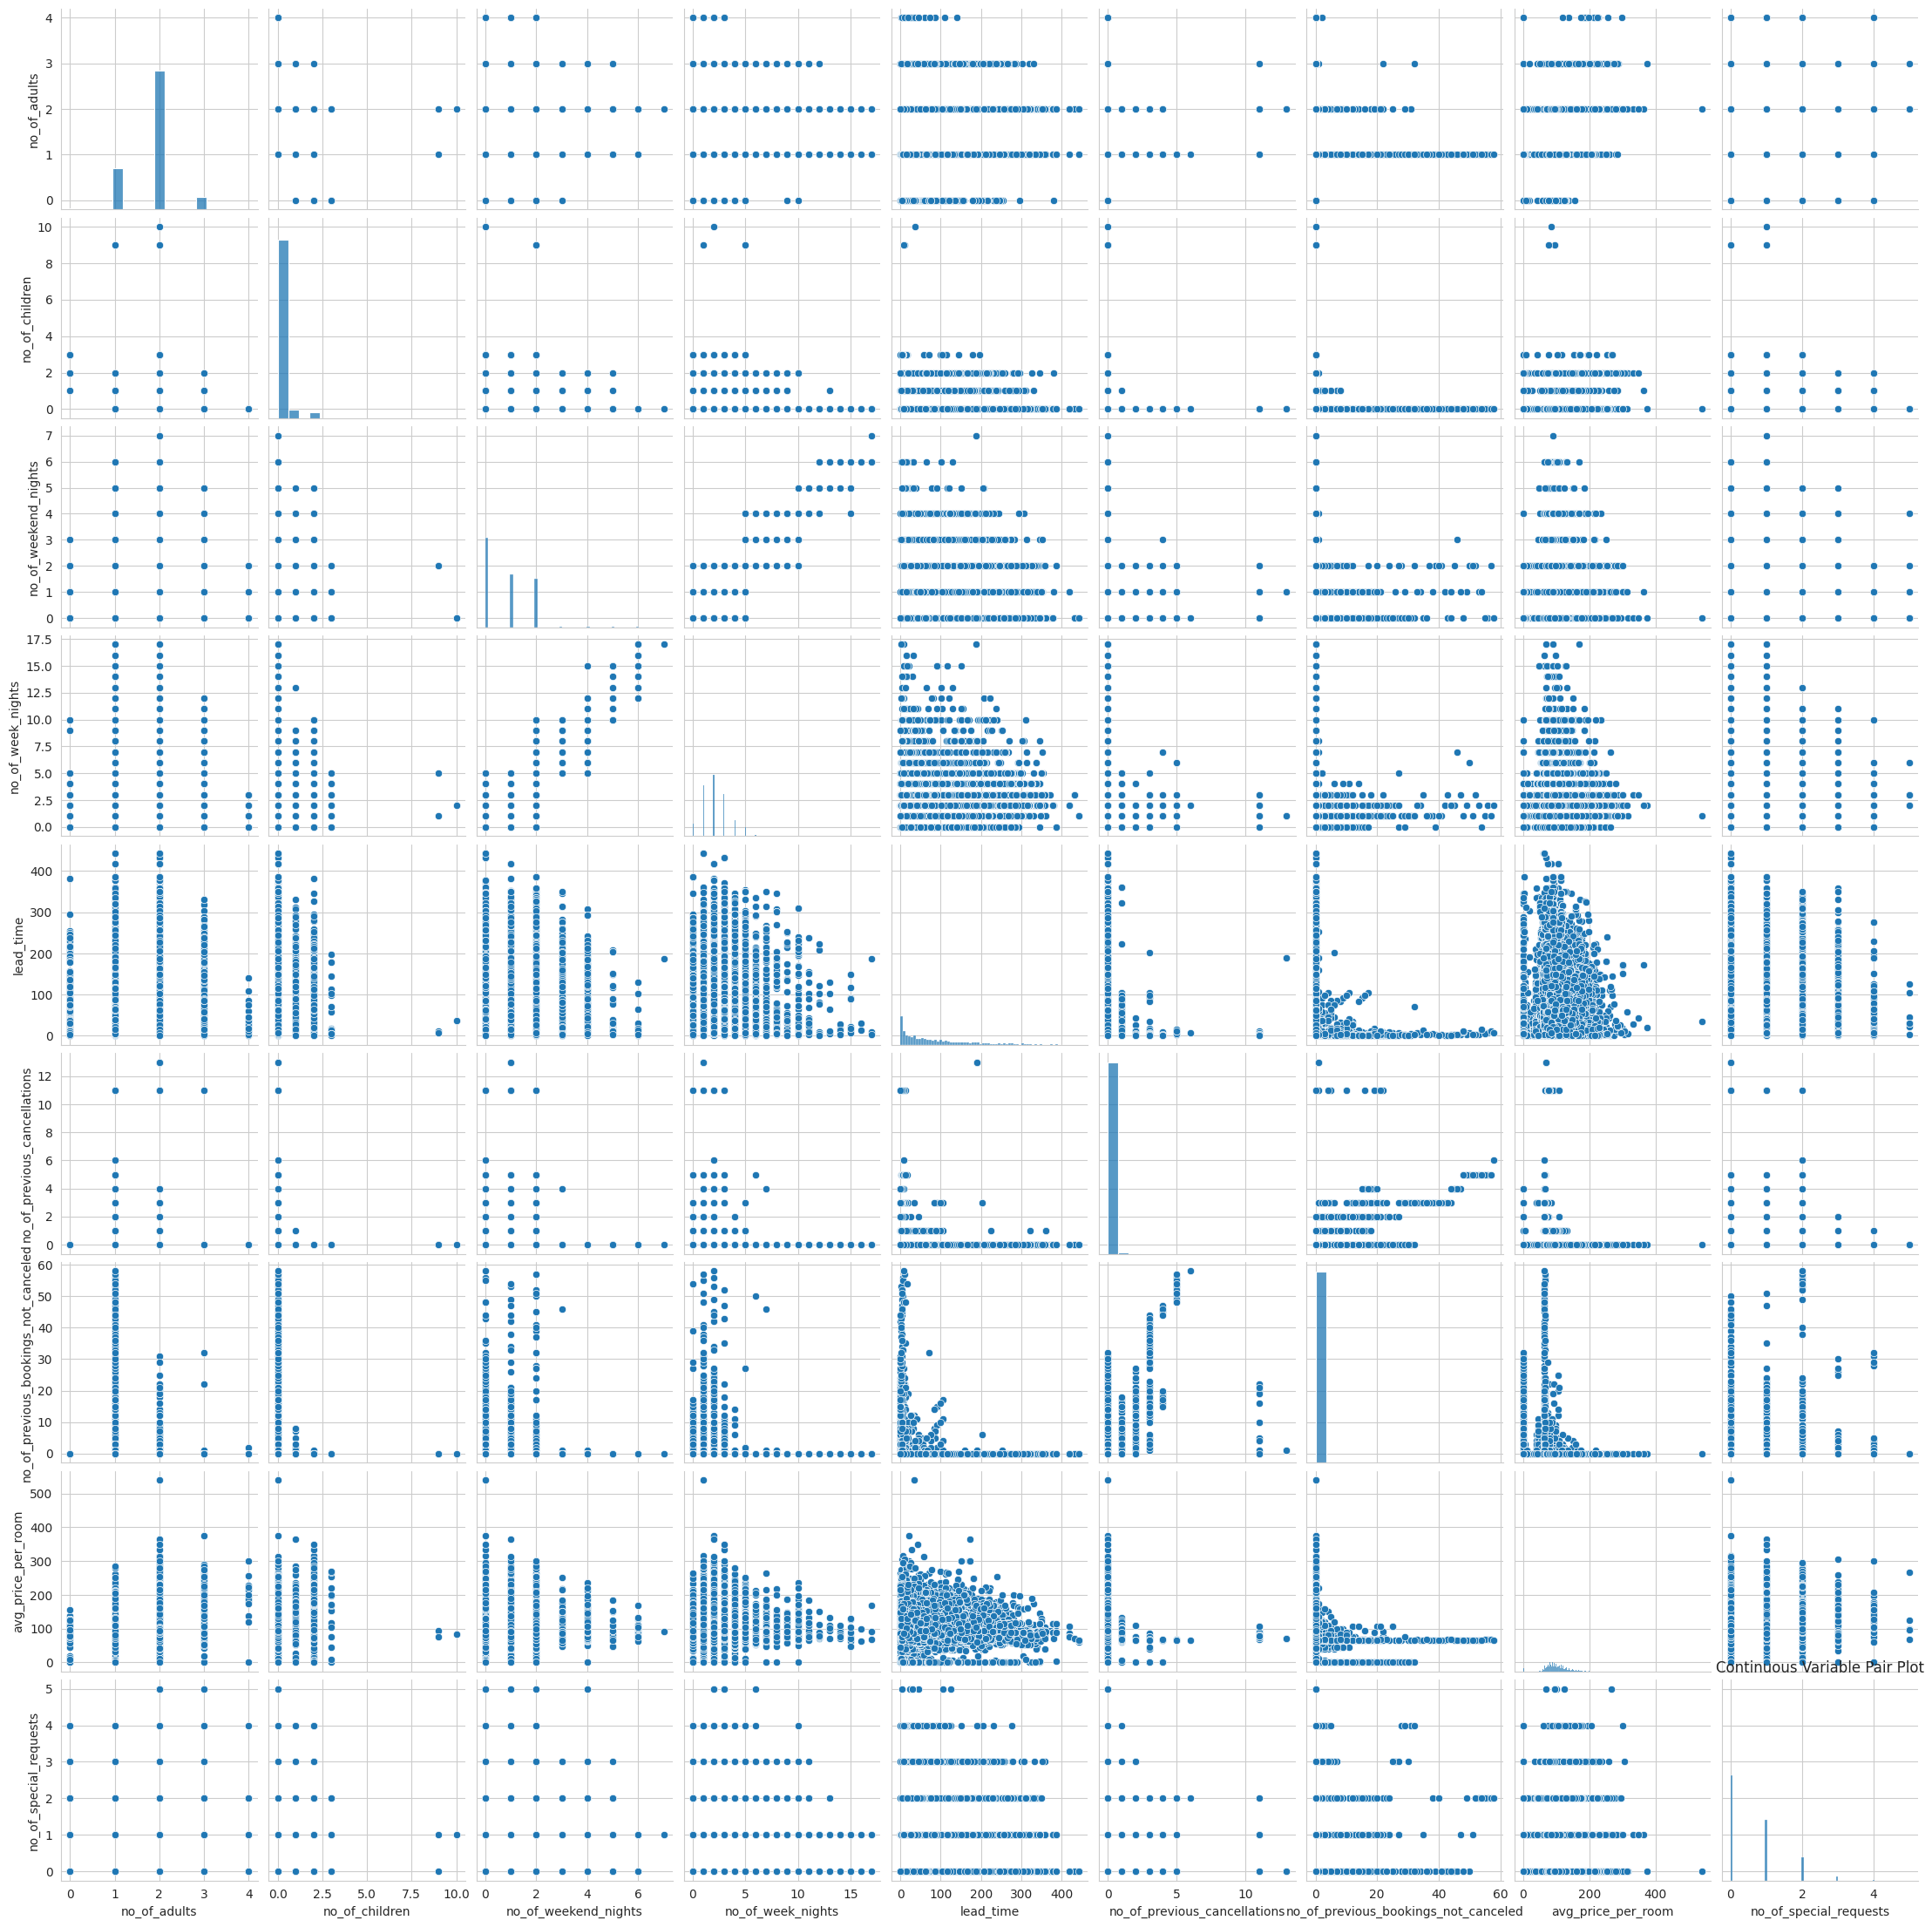

In [ ]:
sns.pairplot(df.select_dtypes(include='number'))
plt.title('Continuous Variable Pair Plot')
plt.show()


Some strong correlations between certain variables. May need to consider removing for logistic regression to avoid multicollinearity.



no_of_adults




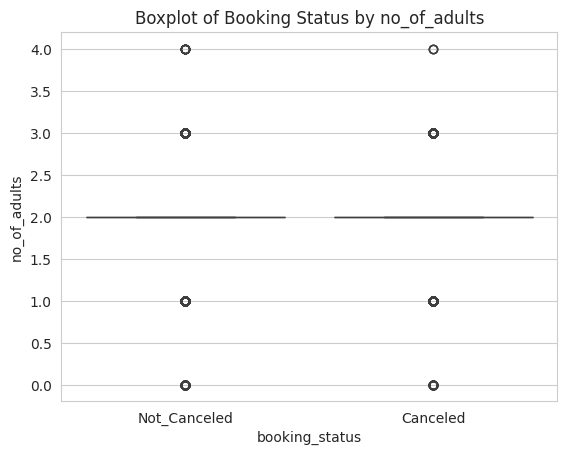



no_of_children




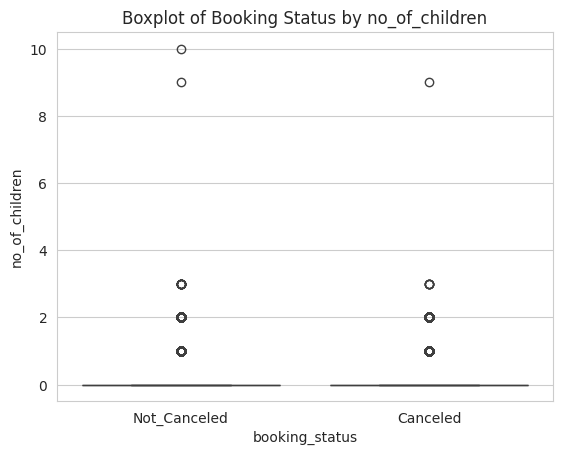



no_of_weekend_nights




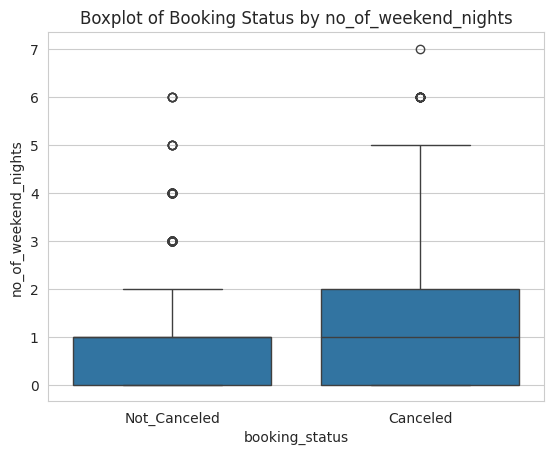



no_of_week_nights




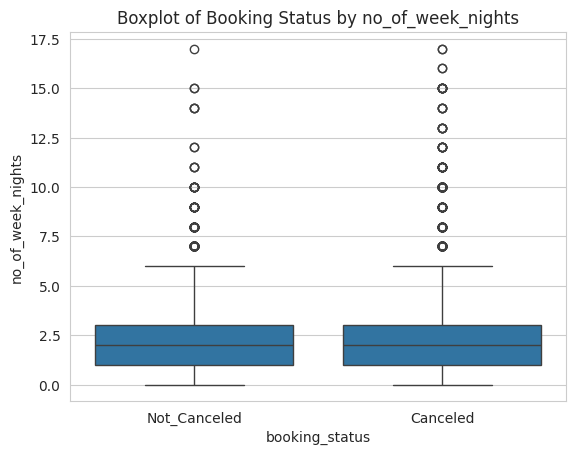



lead_time




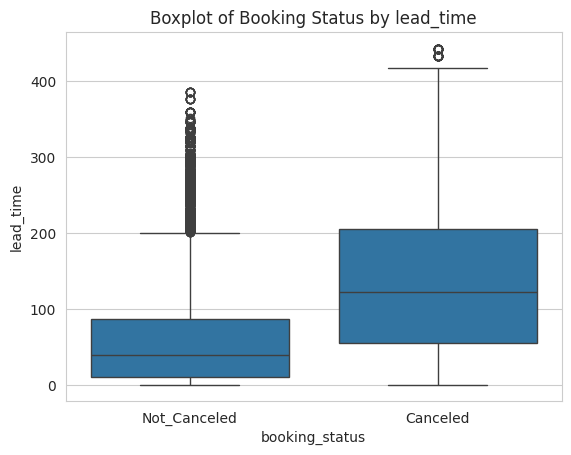



no_of_previous_cancellations




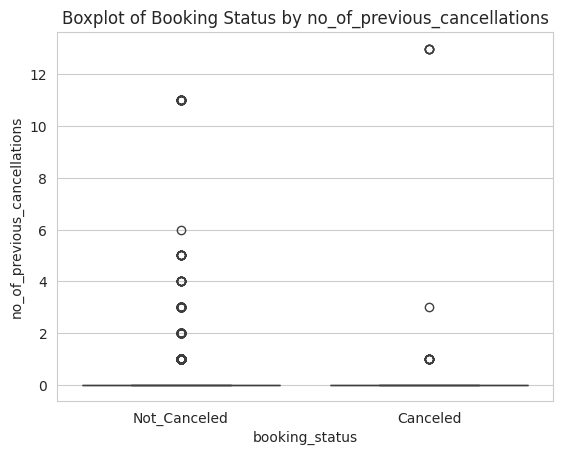



no_of_previous_bookings_not_canceled




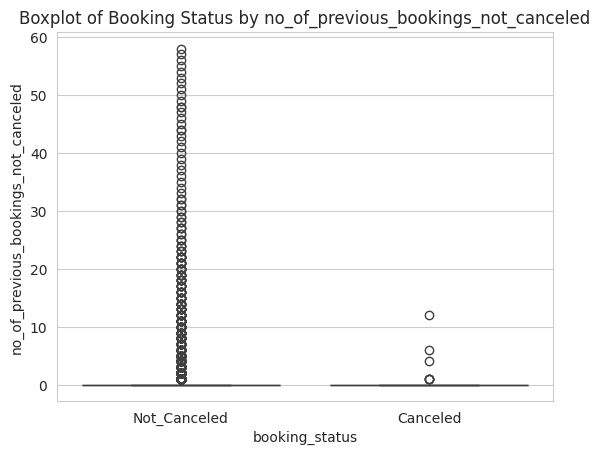



avg_price_per_room




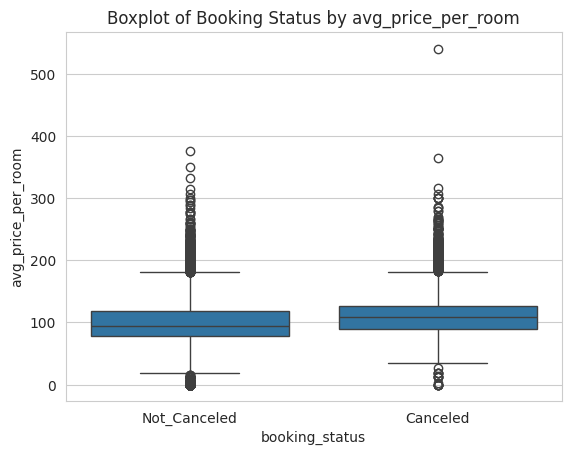



no_of_special_requests




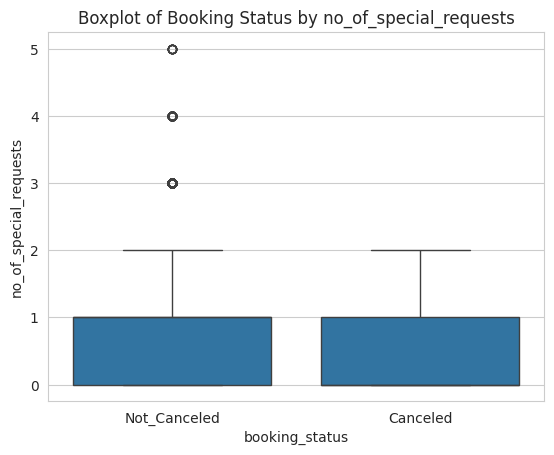

In [ ]:
#Compare booking status with all continuous variables

cont_vars = df.select_dtypes(include='number').columns

for col in cont_vars:
  print(f'\n\n\033[1m{col}\033[0m\n\n')
  sns.boxplot(data=df, x='booking_status', y=col)
  plt.title(f'Boxplot of Booking Status by {col}')
  plt.show()

In [ ]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,No,Room_Type 1,224,2017,10,2,Offline,No,0,0,65.00000,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,No,Room_Type 1,5,2018,11,6,Online,No,0,0,106.68000,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,No,Room_Type 1,1,2018,2,28,Online,No,0,0,60.00000,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,No,Room_Type 1,211,2018,5,20,Online,No,0,0,100.00000,0,Canceled
4,INN00005,2,0,1,1,Not Selected,No,Room_Type 1,48,2018,4,11,Online,No,0,0,94.50000,0,Canceled


When comparing booking status with all continuous variables, most variables show no sign of impacting the number of cancellations.

The variables that do stand out are lead time and number of weekend nights.

Lead time cancelled bookings have a median lead time of around 120 days. Not cancelled bookings have a median lead time of around 50 days but with many outliers above 200 days.

Number of weekend nights cancellations has a median of 1 night while no cancellations a median of 0 nights.



no_of_adults




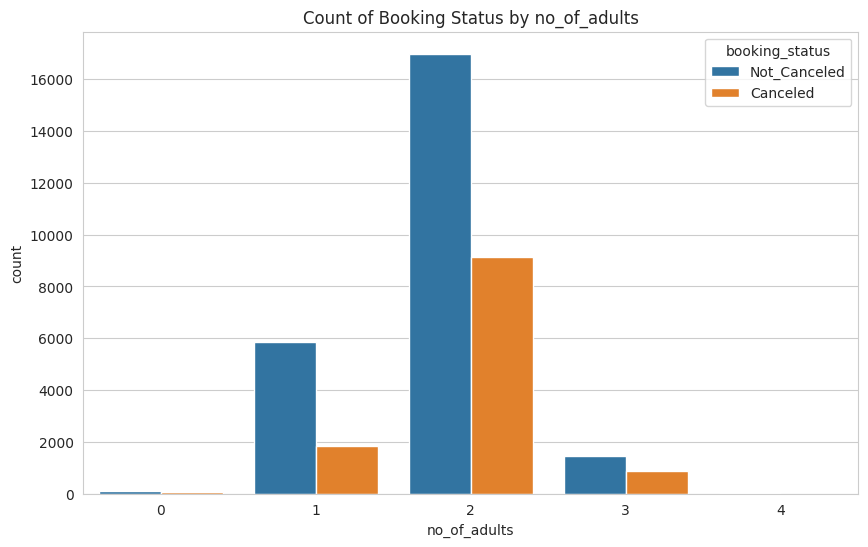



no_of_children




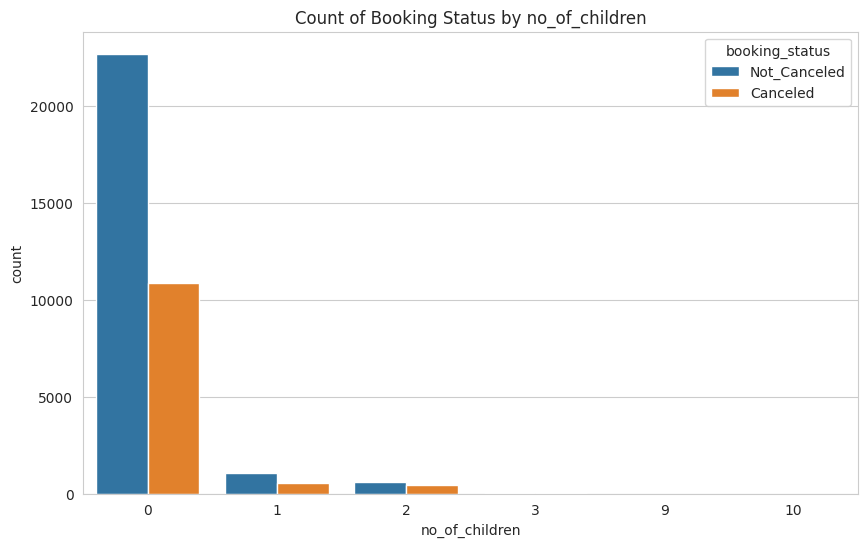



no_of_weekend_nights




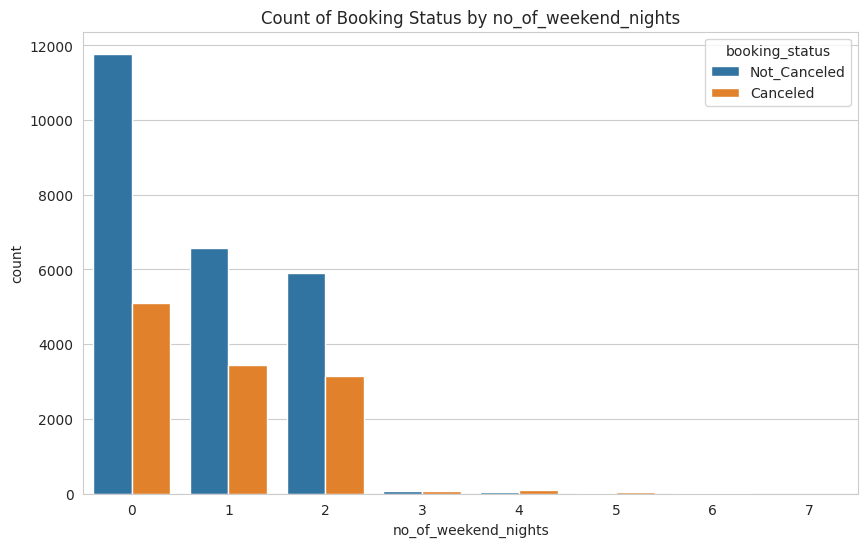



no_of_week_nights




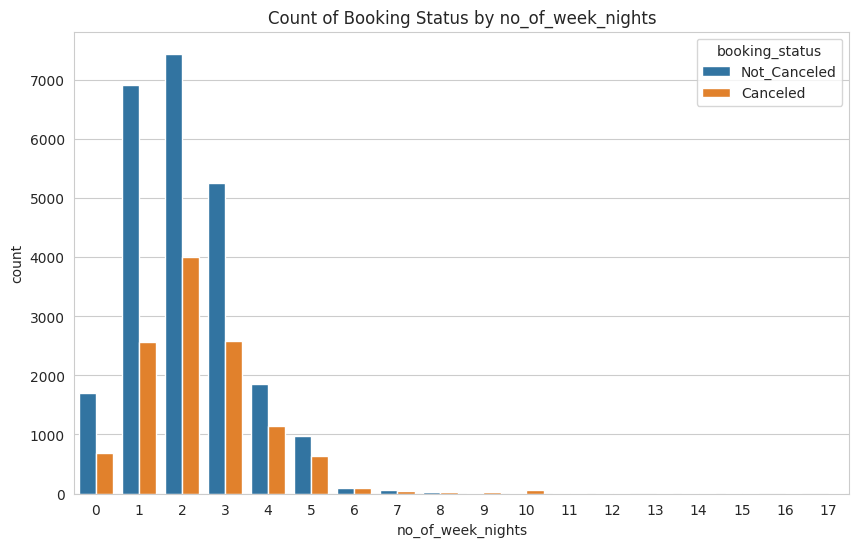



type_of_meal_plan




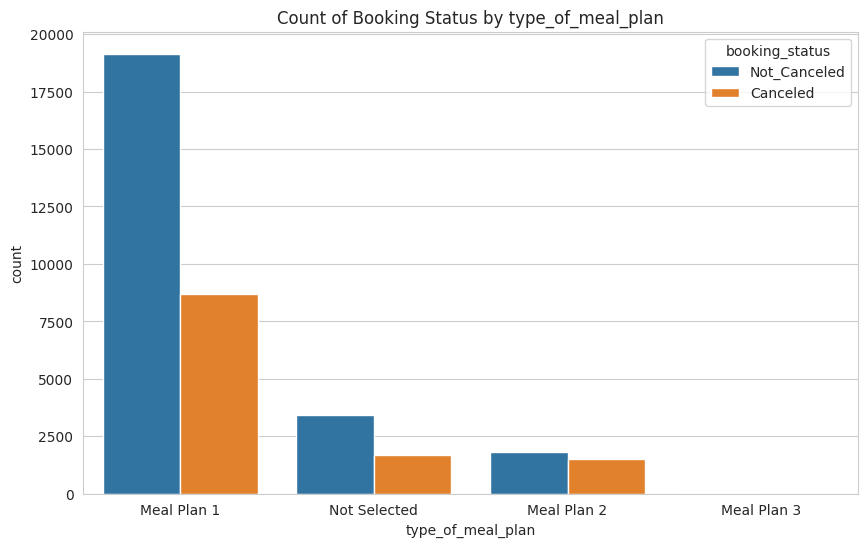



required_car_parking_space




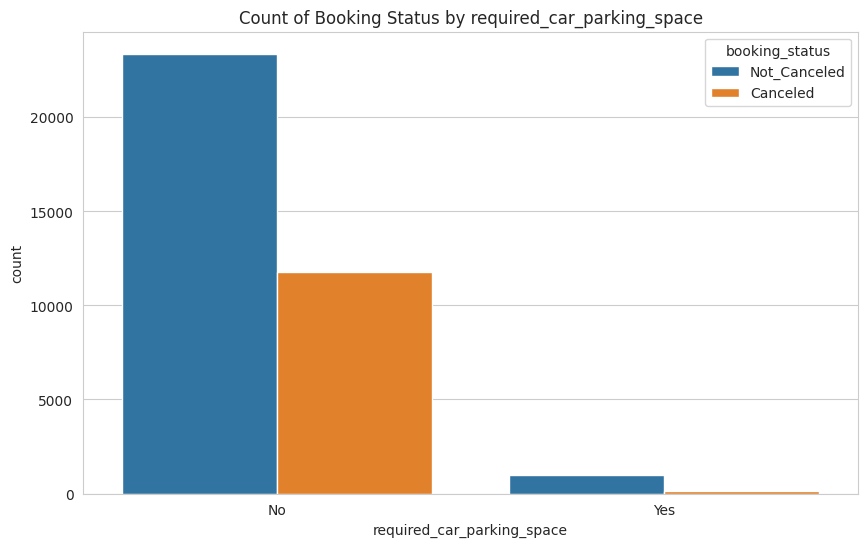



room_type_reserved




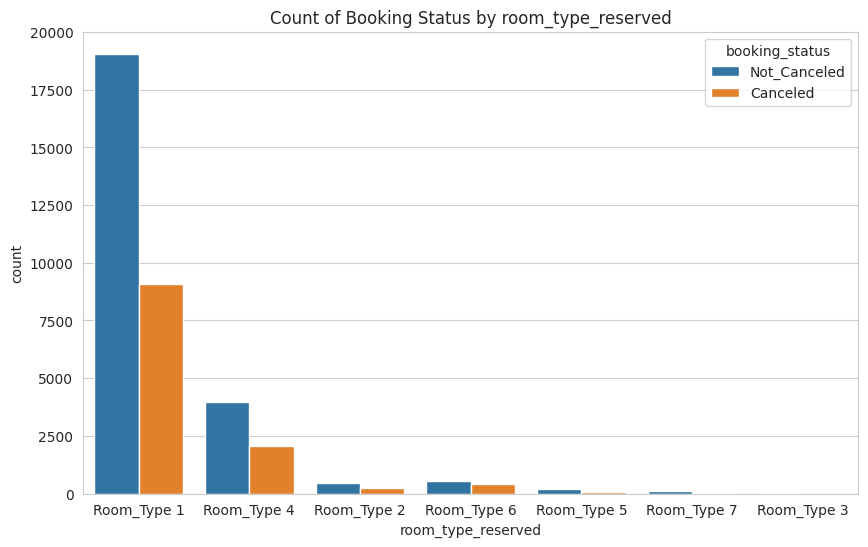



lead_time




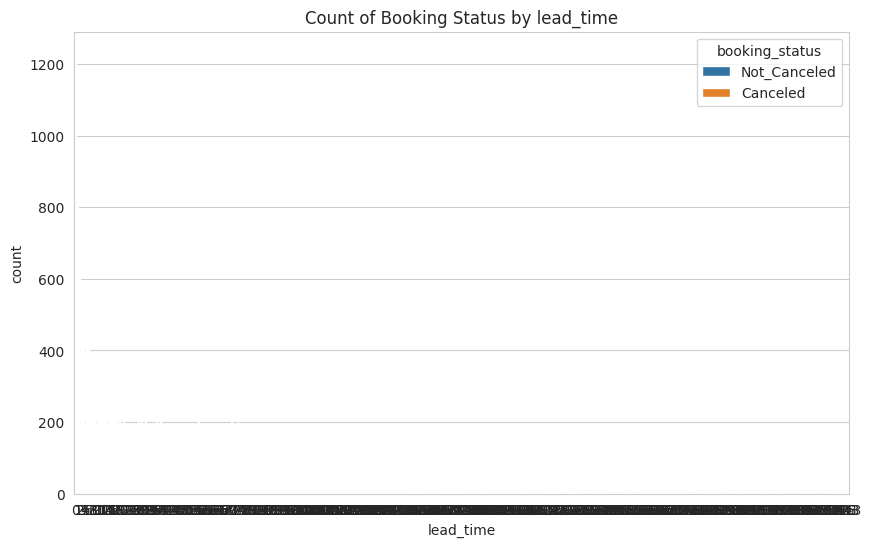



arrival_year




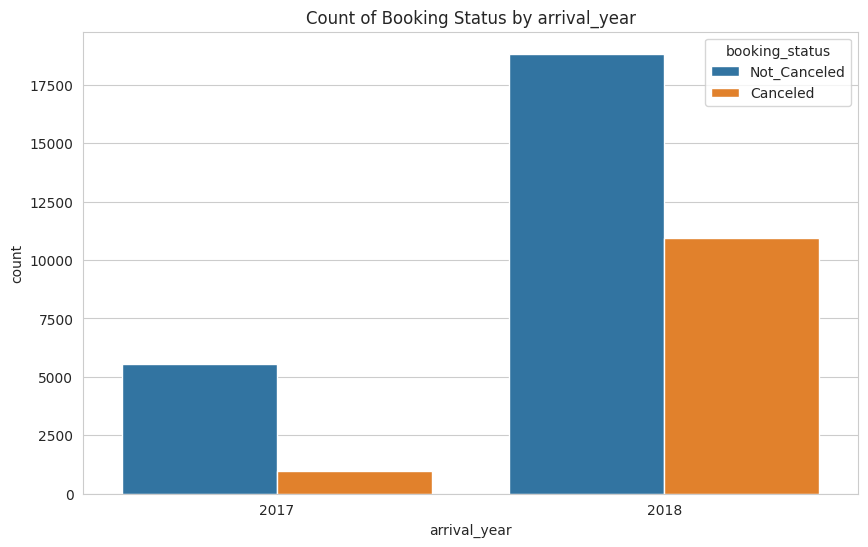



arrival_month




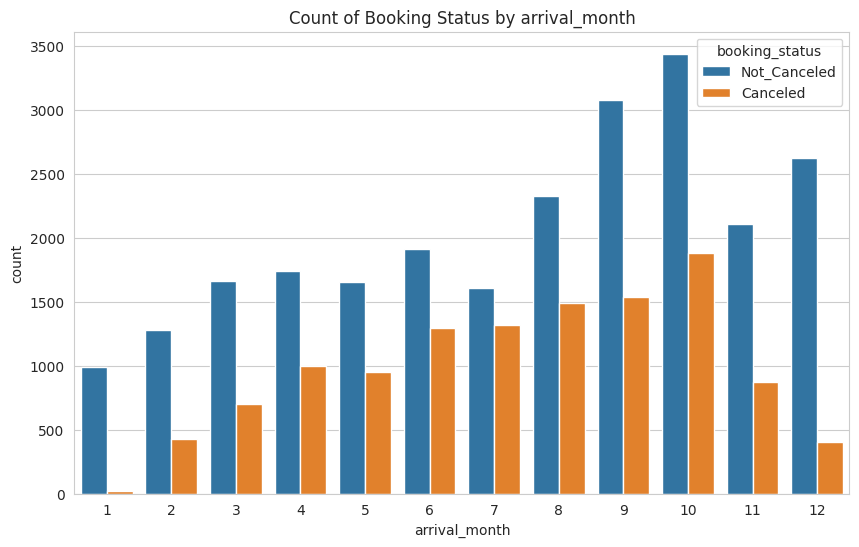



arrival_date




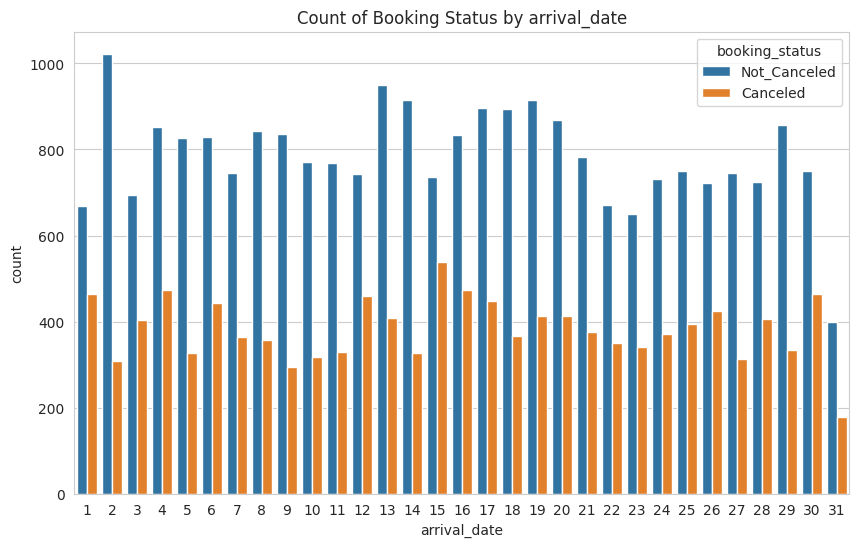



market_segment_type




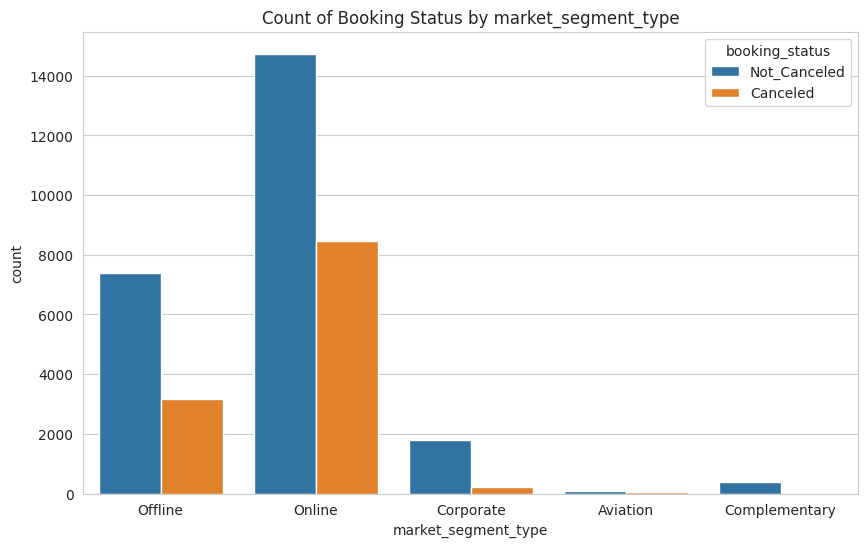



repeated_guest




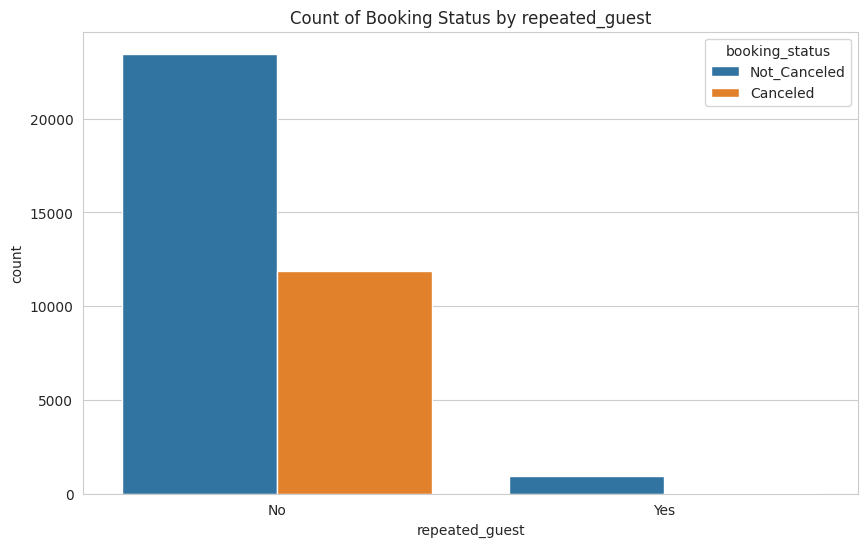



no_of_previous_cancellations




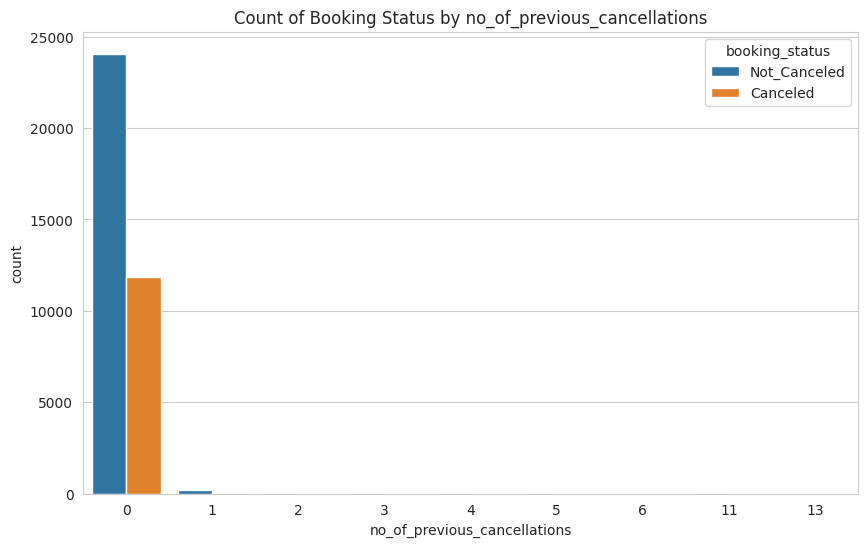



no_of_previous_bookings_not_canceled




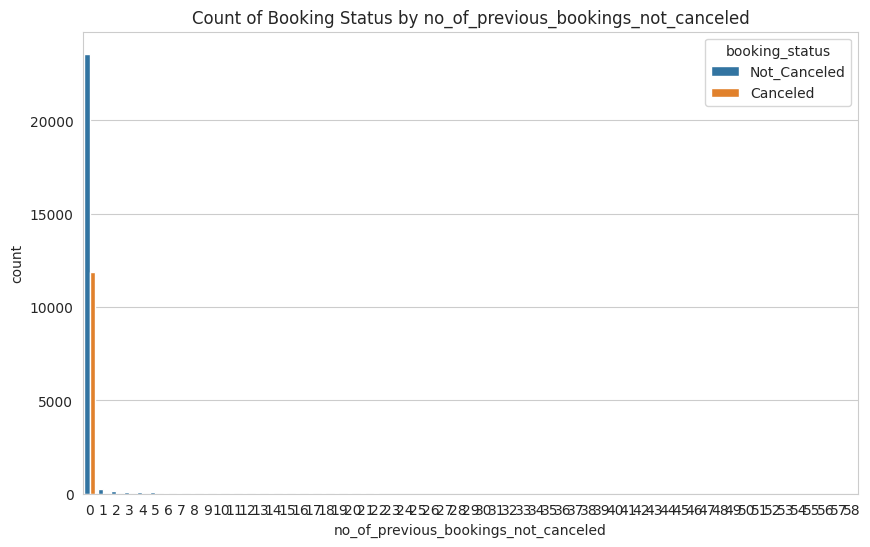



no_of_special_requests




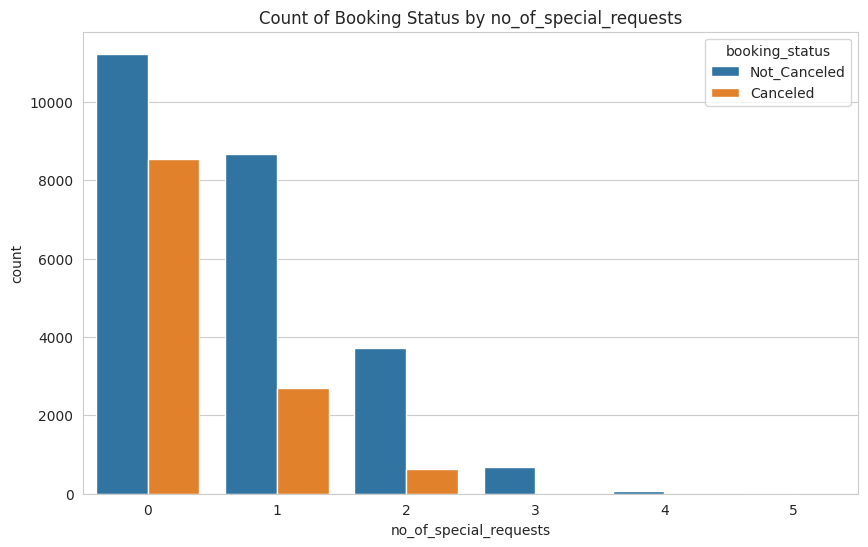

In [ ]:


for col in df.select_dtypes(include=['object','int64']).columns[1:-1]:
  print(f'\n\n\033[1m{col}\033[0m\n\n')
  plt.figure(figsize=(10,6))
  sns.countplot(data=df, x=col, hue='booking_status', hue_order=['Not_Canceled', 'Canceled'])
  plt.title(f'Count of Booking Status by {col}')
  plt.show()

When comparing booking status with all variables using countplot, almost all graphs show that the number of cancellations and not cancellations are proportional to one another, with caancellations having smaller counts than not cancellations.

## Data Preprocessing

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

From initial data analysis, univariate and bivariate analysis, there are no missing values present in the data.

Since a room must be booked by at least 1 adult, the 0 value for number of adults booking rooms does not make sense.

We will replace the 0's with the median adults per room booking.

In [ ]:
#Check number of Adults = 0
df['no_of_adults'].value_counts()

,count
no_of_adults,
2,26108
1,7695
3,2317
0,139
4,16


In [ ]:
#Replace 0 in number of adults with nan values
df['no_of_adults'] = df['no_of_adults'].replace(0, np.nan)
df['no_of_adults'].isna().sum()

np.int64(139)

In [ ]:
#Impute 0 adults booking room to median value
df['no_of_adults'] = df['no_of_adults'].fillna(df['no_of_adults'].median())
df['no_of_adults'].value_counts()

,count
no_of_adults,
2.00000,26247
1.00000,7695
3.00000,2317
4.00000,16


We will One-Hot_Encode the booking status variable to prepare for model building. 1 for Canceled and 0 for Not Canceled.

In [ ]:
#One-Hot_Encode booking status
df['booking_status'] = df['booking_status'].map({'Not_Canceled':0, 'Canceled':1})

In [ ]:
df['type_of_meal_plan'].value_counts()

,count
type_of_meal_plan,
Meal Plan 1,27835
Not Selected,5130
Meal Plan 2,3305
Meal Plan 3,5


In [ ]:
#Set catagorical meal plan to number of meals received based on meal plan

df['type_of_meal_plan'] = df['type_of_meal_plan'].map({'Not Selected':0, 'Meal Plan 1':1, 'Meal Plan 2':2, 'Meal Plan 3':3})
df['type_of_meal_plan'].value_counts()


,count
type_of_meal_plan,
1,27835
0,5130
2,3305
3,5


Online Market type has the majority of guest bookings with offline coming second. The other catagories are very small but can be considered 'offline' options as well. We will therefore lump all non-Online options into the 'offline' group.

In [ ]:
#Make all non-online options 'offline'
df['market_segment_type'] = df['market_segment_type'].map({'Online': 'Online', 'Offline': 'Offline', 'Complementary': 'Offline', 'Corporate': 'Offline', 'Aviation': 'Offline'})
df['market_segment_type'].value_counts()

,count
market_segment_type,
Online,23214
Offline,13061


## EDA

- It is a good idea to explore the data once again after manipulating it.

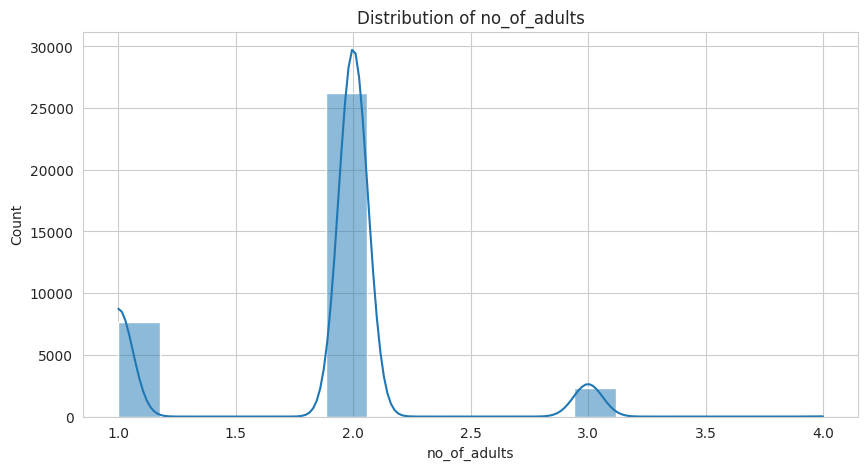

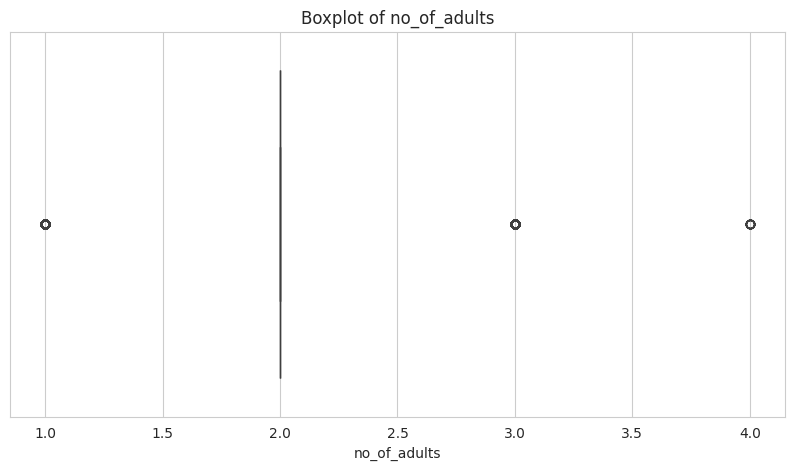

count   36275.00000
mean        1.85263
std         0.50602
min         1.00000
25%         2.00000
50%         2.00000
75%         2.00000
max         4.00000
Name: no_of_adults, dtype: float64


In [ ]:
#Check number of adults grpah after imputation
uni_analy_cont('no_of_adults')

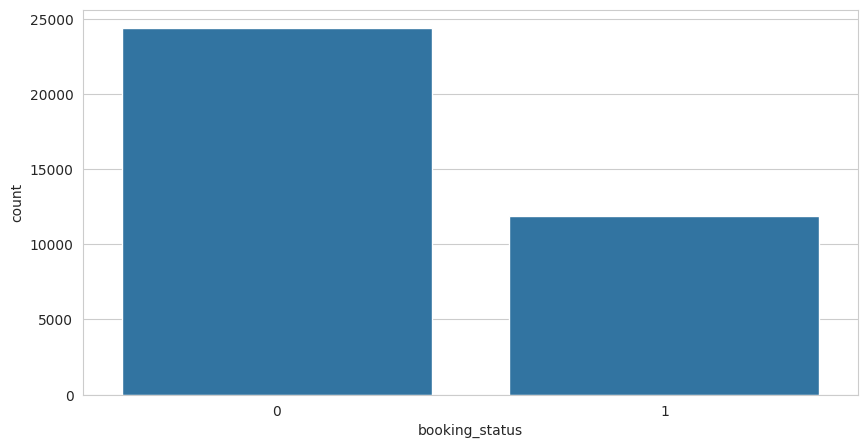

booking_status
0    24390
1    11885
Name: count, dtype: int64


In [ ]:
#Check Booking Status values after One-Hot_Encoding
uni_analy_cat('booking_status')

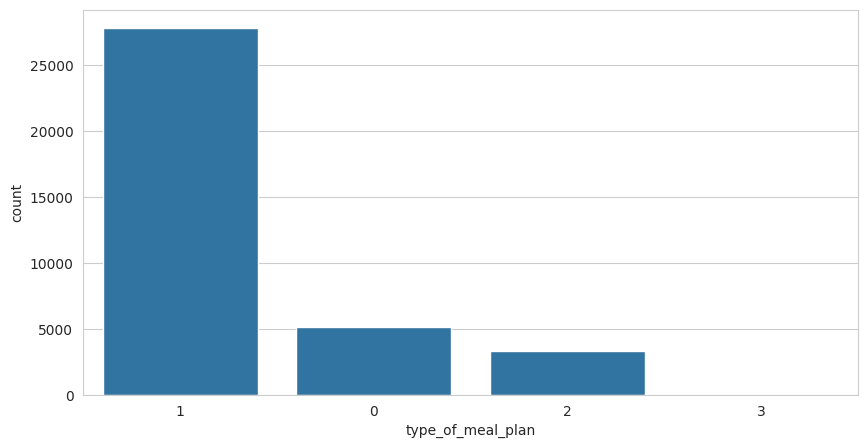

type_of_meal_plan
1    27835
0     5130
2     3305
3        5
Name: count, dtype: int64


In [ ]:
#Check countplot for type of meal plan
uni_analy_cat('type_of_meal_plan')

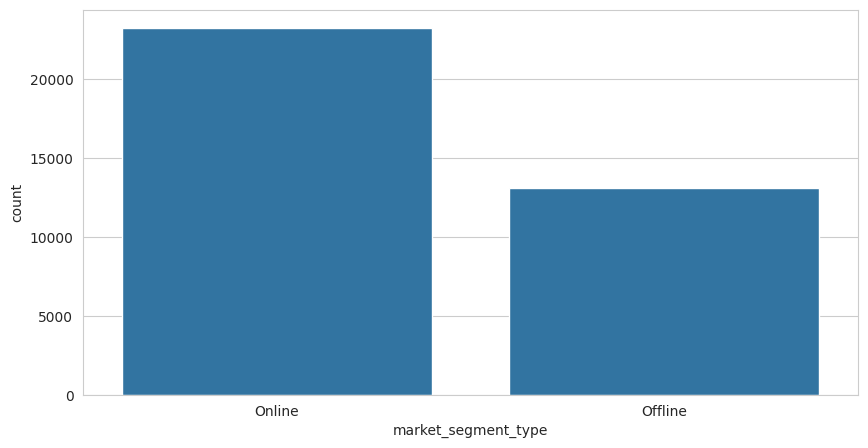

market_segment_type
Online     23214
Offline    13061
Name: count, dtype: int64


In [ ]:
#Check countplot for type of market_segment_type
uni_analy_cat('market_segment_type')

## Building a Logistic Regression model

In [ ]:
#Create X and Y variables
X = df.drop(["booking_status","Booking_ID"], axis=1)
Y = df["booking_status"]

# adding a contstant to X variable
X = add_constant(X)

# creating dummies
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)


# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y
)

In [ ]:
#Build first logistic regression model with all variables
logit = sm.Logit(y_train, X_train.astype(float))
lg = logit.fit()

Optimization terminated successfully.
         Current function value: 0.408703
         Iterations 15


In [ ]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25330
Method:                           MLE   Df Model:                           61
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.3538
Time:                        00:35:04   Log-Likelihood:                -10378.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -7.1105      0.313    -22.751      0.000      -7.723      -6.498
no_of_adults                             0.0394      

## Model performance evaluation

In [ ]:
#Function to generate confusion matrix
def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
#Predicted training data for initial model
pred_train = lg.predict(X_train) > 0.5
pred_train = np.round(pred_train)

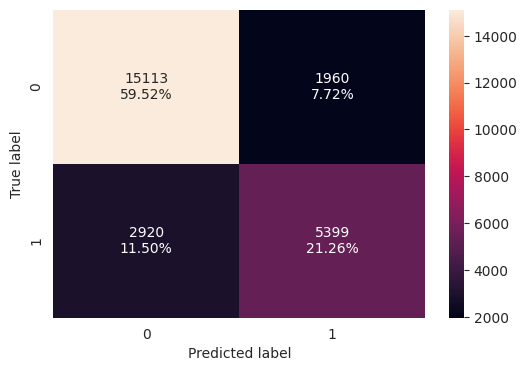

In [ ]:
#Confusion matrix for initial model
confusion_matrix_statsmodels(lg, X_train, y_train)

In [ ]:
#Accuracy, Recall, Precision, F1 scores for initial model
model_performance_classification_statsmodels(lg, X_train, y_train)

,Accuracy,Recall,Precision,F1
0,0.80781,0.64900,0.73366,0.68874


## Checking Multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

In [ ]:
#Generate VIF scores for initial model
vif_series = pd.Series(
    [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
    index=X_train.columns,
    dtype=float,
)
print("Series before feature selection: \n\n{}\n".format(vif_series))

Series before feature selection: 

const                                  99.95703
no_of_adults                            1.33492
no_of_children                          2.00027
no_of_weekend_nights                    1.07938
no_of_week_nights                       1.09962
type_of_meal_plan                       1.45845
lead_time                               1.46985
no_of_previous_cancellations            1.32281
no_of_previous_bookings_not_canceled    1.56828
avg_price_per_room                      2.13510
no_of_special_requests                  1.24768
required_car_parking_space_Yes          1.03788
room_type_reserved_Room_Type 2          1.09692
room_type_reserved_Room_Type 3          1.00385
room_type_reserved_Room_Type 4          1.28890
room_type_reserved_Room_Type 5          1.01972
room_type_reserved_Room_Type 6          1.97437
room_type_reserved_Room_Type 7          1.05652
arrival_year_2018                       1.55888
arrival_month_2                         2.64755
arriv

All values for VIF are less than 5 indicating minimal multicollinearity of all the variables

We will now begin removing high p-value variables.

##Dropping p-values

In [ ]:
X_train2 = X_train.drop(["arrival_date_28","arrival_date_19","arrival_date_16","arrival_date_15","arrival_date_12","arrival_date_30","arrival_date_26"], axis=1)

In [ ]:
logit2 = sm.Logit(y_train, X_train2.astype(float))
lg2 = logit2.fit()
print(lg2.summary())

Optimization terminated successfully.
         Current function value: 0.408734
         Iterations 15
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25337
Method:                           MLE   Df Model:                           54
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.3538
Time:                        00:35:20   Log-Likelihood:                -10379.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -7.1186      0.

In [ ]:
X_train3 = X_train2.drop(["room_type_reserved_Room_Type 3", "no_of_adults", "no_of_previous_bookings_not_canceled"], axis=1)

In [ ]:
logit3 = sm.Logit(y_train, X_train3.astype(float))
lg3 = logit3.fit()
print(lg3.summary())

Optimization terminated successfully.
         Current function value: 0.408870
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25340
Method:                           MLE   Df Model:                           51
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.3535
Time:                        00:35:20   Log-Likelihood:                -10382.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -7.0610      0.293    -24.135    

In [ ]:
X_train4 = X_train3.drop(["arrival_date_31", "arrival_date_27", "arrival_date_8"], axis=1)

In [ ]:
logit4 = sm.Logit(y_train, X_train4.astype(float))
lg4 = logit4.fit()
print(lg4.summary())

Optimization terminated successfully.
         Current function value: 0.408979
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25343
Method:                           MLE   Df Model:                           48
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.3534
Time:                        00:35:21   Log-Likelihood:                -10385.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -7.0924      0.292    -24.264    

In [ ]:
X_train5 = X_train4.drop(["arrival_date_25", "arrival_date_20", "arrival_date_18", "arrival_date_4"], axis=1)

In [ ]:
logit5 = sm.Logit(y_train, X_train5.astype(float))
lg5 = logit5.fit()
print(lg5.summary())

Optimization terminated successfully.
         Current function value: 0.409126
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25347
Method:                           MLE   Df Model:                           44
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.3531
Time:                        00:35:21   Log-Likelihood:                -10389.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -7.1356      0.292    -24.440    

In [ ]:
X_train6 = X_train5.drop(["arrival_date_22", "arrival_date_17", "arrival_date_6"], axis=1)

In [ ]:
logit6 = sm.Logit(y_train, X_train6.astype(float))
lg6 = logit6.fit()
print(lg6.summary())

Optimization terminated successfully.
         Current function value: 0.409267
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25350
Method:                           MLE   Df Model:                           41
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.3529
Time:                        00:35:22   Log-Likelihood:                -10392.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -7.1551      0.292    -24.519    

In [ ]:
X_train7 = X_train6.drop(["arrival_date_11", "type_of_meal_plan", "no_of_children"], axis=1)

In [ ]:
logit7 = sm.Logit(y_train, X_train7.astype(float))
lg7 = logit7.fit()
print(lg7.summary())

Optimization terminated successfully.
         Current function value: 0.409450
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25353
Method:                           MLE   Df Model:                           38
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.3526
Time:                        00:35:22   Log-Likelihood:                -10397.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -7.2554      0.289    -25.138    

In [ ]:
#Create training predictions for latest model after dropping variables
pred_train7 = lg7.predict(X_train7) > 0.5
pred_train7 = np.round(pred_train7)

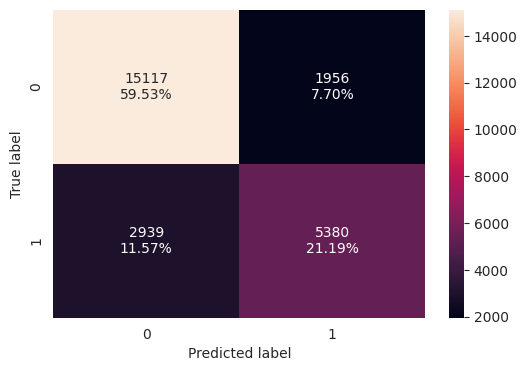

In [ ]:
#Confusion matrix after dropping variables
confusion_matrix_statsmodels(lg7, X_train7, y_train)

In [ ]:
#Accuracy, recall, Precision, F1 scores after dropping variables
log_reg_model_train_perf = model_performance_classification_statsmodels(
    lg7, X_train7, y_train
)

print("Test performance:")
log_reg_model_train_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.80722,0.64671,0.73337,0.68732


In [ ]:
#VIF scores after dropping variables
vif_series7 = pd.Series(
    [variance_inflation_factor(X_train7.values, i) for i in range(X_train7.shape[1])],
    index=X_train7.columns,
    dtype=float,
)
print("Series before feature selection: \n\n{}\n".format(vif_series7))

Series before feature selection: 

const                            52.09970
no_of_weekend_nights              1.06762
no_of_week_nights                 1.09219
lead_time                         1.30809
no_of_previous_cancellations      1.18652
avg_price_per_room                1.84204
no_of_special_requests            1.21450
required_car_parking_space_Yes    1.03606
room_type_reserved_Room_Type 2    1.02385
room_type_reserved_Room_Type 4    1.19172
room_type_reserved_Room_Type 5    1.01757
room_type_reserved_Room_Type 6    1.25936
room_type_reserved_Room_Type 7    1.03303
arrival_year_2018                 1.42655
arrival_month_2                   2.62512
arrival_month_3                   3.23387
arrival_month_4                   3.60259
arrival_month_5                   3.52319
arrival_month_6                   4.08660
arrival_month_7                   3.92485
arrival_month_8                   4.75214
arrival_month_9                   5.58105
arrival_month_10                  5.99641

All p-values are less than 5% and VIF is at or less than 5 for all variables.

We will now check the model for the test data.

## Check Model on Testing Data

In [ ]:
#Drop same variables of test data as training data
X_test7 = X_test[list(X_train7.columns)]

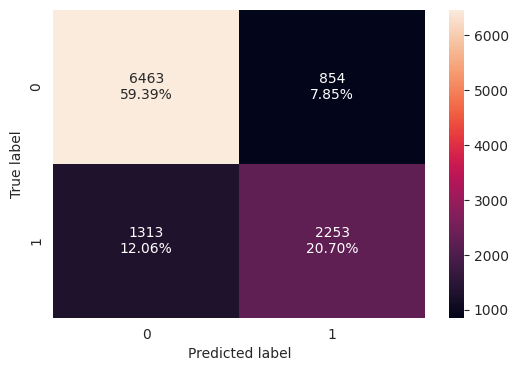

In [ ]:
#Test data confusion matrix
confusion_matrix_statsmodels(lg7, X_test7, y_test)

In [ ]:
log_reg_model_test_perf = model_performance_classification_statsmodels(
    lg7, X_test7, y_test
)

print("Test performance:")
log_reg_model_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.80088,0.63180,0.72514,0.67526


The result of the training and test data are similar which is good, but in our case, the recall score should be made as high as possible.

Since booking cacellations are our biggest problem and have high cost, we want to minimize the amount of False Negatives (bookings predicted to not be cancelled but are cancelled) in our model.

We can try testing different threshold values to achieve this.

## Get Optimal Threshold Value

### Area Under Curve

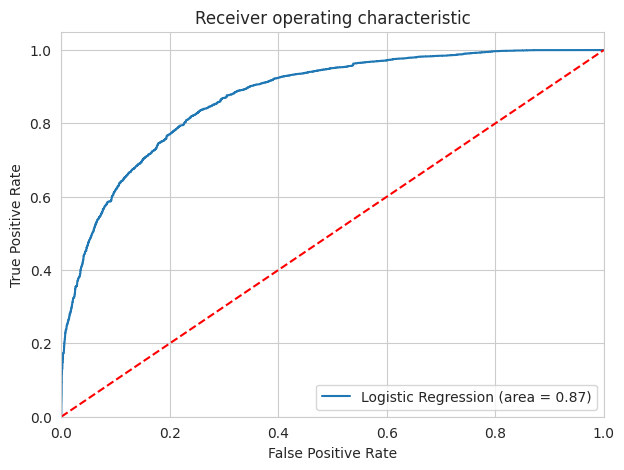

In [ ]:
#Check area under curve graph to measure performance and optimal threshold value
logit_roc_auc_train = roc_auc_score(y_train, lg7.predict(X_train7))
fpr, tpr, thresholds = roc_curve(y_train, lg7.predict(X_train7))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = roc_curve(y_train, lg7.predict(X_train7))

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(optimal_threshold_auc_roc)

0.29623075749629757


The area under the curve is 0.87 indicating we have a good model. An optimal threshold value of 0.296 will be tested to check its impact on accuracy, precision, recall, and F1 scores.

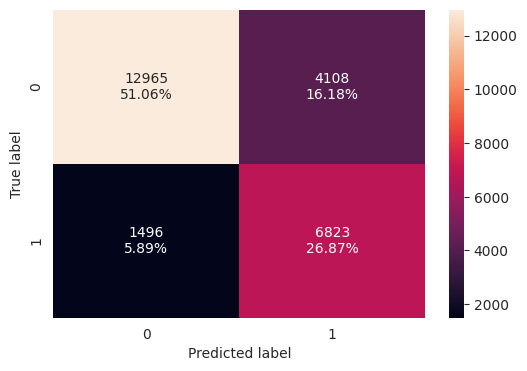

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(
    lg7, X_train7, y_train, threshold=optimal_threshold_auc_roc
)

In [ ]:
# checking model performance for this model
log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lg7, X_train7, y_train, threshold=optimal_threshold_auc_roc
)
print("Training performance:")
log_reg_model_train_perf_threshold_auc_roc

Training performance:


,Accuracy,Recall,Precision,F1
0,0.77930,0.82017,0.62419,0.70888


The threshold of 0.296 improved the recall score substantially while also improving teh F1 score. Accuracy and precision dropped slightly.

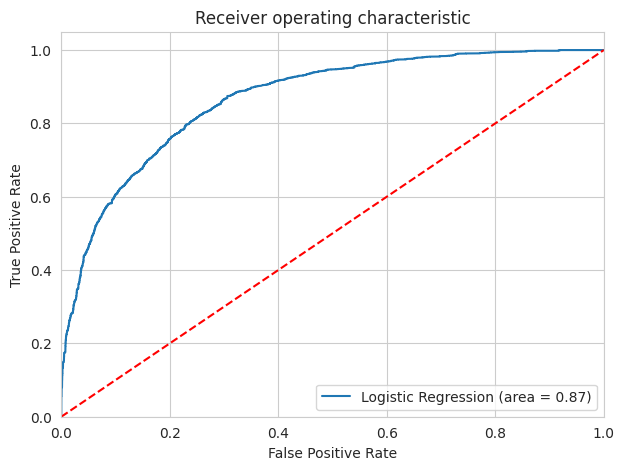

In [ ]:
#Threshold 0.296 test data area under curve
logit_roc_auc_train = roc_auc_score(y_test, lg7.predict(X_test7))
fpr, tpr, thresholds = roc_curve(y_test, lg7.predict(X_test7))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

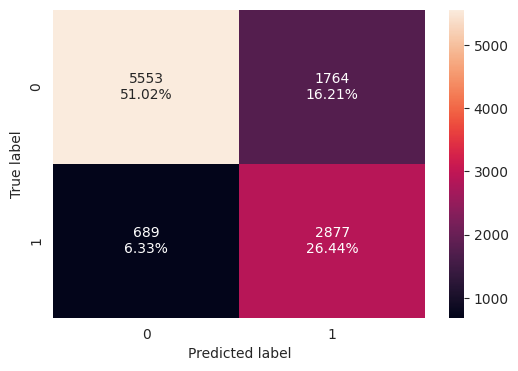

In [ ]:
#Threshold 0.296 test data confusion matrix
confusion_matrix_statsmodels(lg7, X_test7, y_test, threshold=optimal_threshold_auc_roc)

In [ ]:
# checking model performance for this model
log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lg7, X_test7, y_test, threshold=optimal_threshold_auc_roc
)
print("Test performance:")
log_reg_model_test_perf_threshold_auc_roc

Test performance:


,Accuracy,Recall,Precision,F1
0,0.77460,0.80679,0.61991,0.70111


After performing the same model and threshold on the test data, we get a similar result to our training data in terms of the confusion matrix, accuracy, precision, recall, and F1 scores, and the area under the curve.


To try a different flavor for deriving the threshold, we will try the recall/precision threshold to see if we can get precision and recall as close as possible to one another and if it will outperform the recall score using the threshold of 0.296.

### Precision/Recall Plot

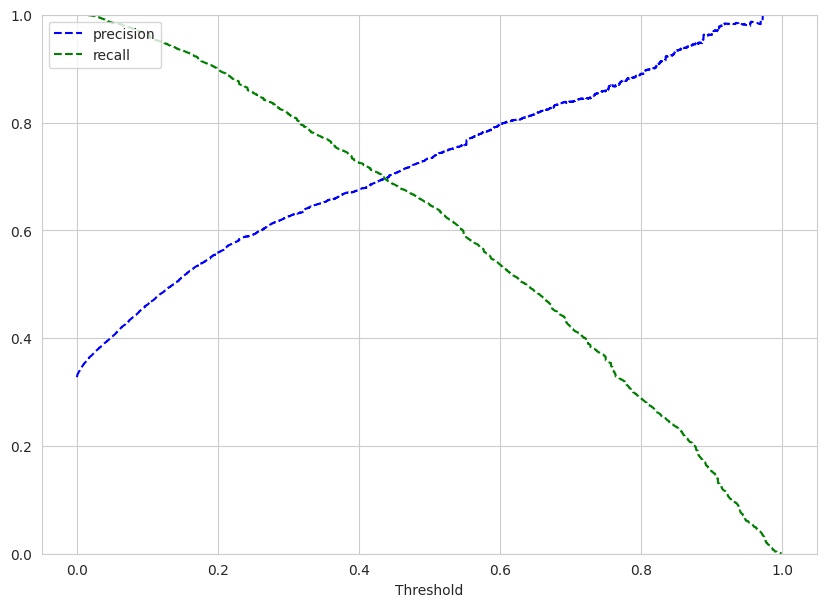

In [ ]:
#Create Precision/Recall plot
y_scores = lg7.predict(X_train7)
prec, rec, tre = precision_recall_curve(y_train, y_scores,)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])


plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

In [ ]:
#Optimal thresh value from precision/recall plot
optimal_threshold_curve = 0.435

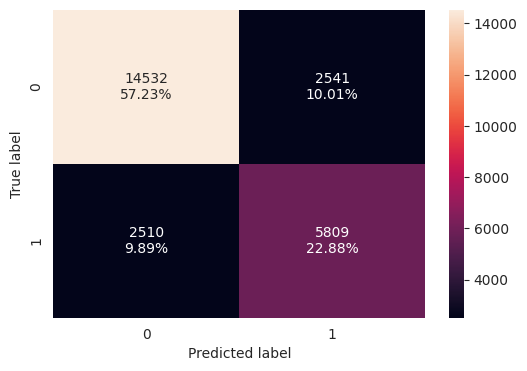

In [ ]:
#Confusion Matrix of model using 0.435 threshold for training data
confusion_matrix_statsmodels(lg7, X_train7, y_train, threshold=optimal_threshold_curve)

In [ ]:
#0.435 threshold performance for training data
log_reg_model_train_perf_threshold_curve = model_performance_classification_statsmodels(
    lg7, X_train7, y_train, threshold=optimal_threshold_curve
)
print("Training performance:")
log_reg_model_train_perf_threshold_curve

Training performance:


,Accuracy,Recall,Precision,F1
0,0.80108,0.69828,0.69569,0.69698


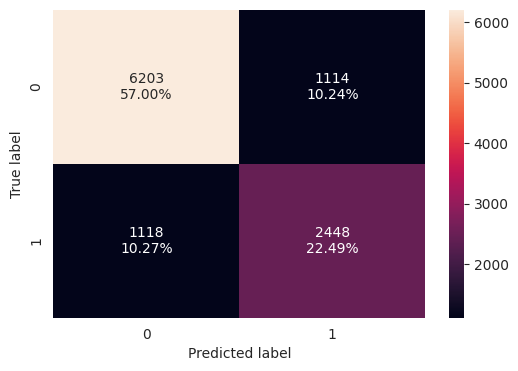

In [ ]:
#Threshold 0.435 test data confusion matrix
confusion_matrix_statsmodels(lg7, X_test7, y_test, threshold=optimal_threshold_curve)

In [ ]:
log_reg_model_test_perf_threshold_curve = model_performance_classification_statsmodels(
    lg7, X_test7, y_test, threshold=optimal_threshold_curve
)
print("Test performance:")
log_reg_model_test_perf_threshold_curve

Test performance:


,Accuracy,Recall,Precision,F1
0,0.79491,0.68648,0.68725,0.68687


### Comparison of 0.5 (default), 0.296, and 0.435 Thresholds

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        log_reg_model_train_perf.T,
        log_reg_model_train_perf_threshold_auc_roc.T,
        log_reg_model_train_perf_threshold_curve.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression-default Threshold (0.5)",
    "Logistic Regression-0.296 Threshold",
    "Logistic Regression-0.435 Threshold",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression-default Threshold (0.5),Logistic Regression-0.296 Threshold,Logistic Regression-0.435 Threshold
Accuracy,0.80722,0.77930,0.80108
Recall,0.64671,0.82017,0.69828
Precision,0.73337,0.62419,0.69569
F1,0.68732,0.70888,0.69698


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        log_reg_model_test_perf.T,
        log_reg_model_test_perf_threshold_auc_roc.T,
        log_reg_model_test_perf_threshold_curve.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression-default Threshold (0.5)",
    "Logistic Regression-0.296 Threshold",
    "Logistic Regression-0.435 Threshold",
]

print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Logistic Regression-default Threshold (0.5),Logistic Regression-0.296 Threshold,Logistic Regression-0.435 Threshold
Accuracy,0.80088,0.77460,0.79491
Recall,0.63180,0.80679,0.68648
Precision,0.72514,0.61991,0.68725
F1,0.67526,0.70111,0.68687


No matter the threshold value used, all training and testing data sets using this model are consistent.

The best model for our case is the threshold of 0.296:

- Accuracy within an acceptable range for the model

- Recall is the highest at 0.81 meaning we will minimize the amount of false negatives (false no cancellations).

- Precision is at 0.61, but for our case, we would much rather have a False psoitive than a false negative (we would rather predict a false cancellation than a false no cancellation).

- F1 is highest here due to the lower recall and precision scores for the other two thresholds.


## Final Model Summary

### Create Final Model

In [ ]:
logit_Final = sm.Logit(y_train, X_train7.astype(float), thresholds=0.296)
lg_Final = logit_Final.fit()
print(lg_Final.summary())

Optimization terminated successfully.
         Current function value: 0.409450
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25353
Method:                           MLE   Df Model:                           38
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.3526
Time:                        00:35:32   Log-Likelihood:                -10397.
converged:                       True   LL-Null:                       -16060.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                             -7.2554      0.289    -25.138    

### Check Training/Testing Confusion Matrix and Accuracy, Precision, Recall, and F1 Scores

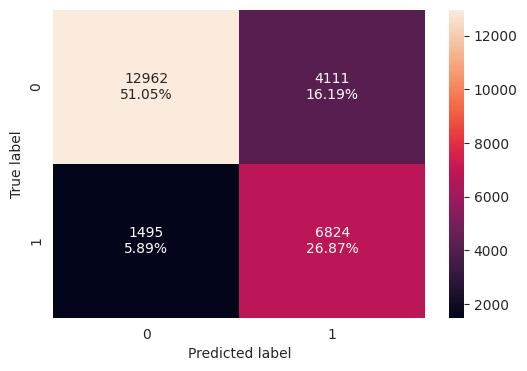

In [ ]:
confusion_matrix_statsmodels(lg_Final, X_train7, y_train, threshold=0.296)

In [ ]:
# checking model performance for this model
final_log_reg_model_train_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lg7, X_train7, y_train, threshold=0.296
)
print("Training performance:")
log_reg_model_train_perf_threshold_auc_roc

Training performance:


,Accuracy,Recall,Precision,F1
0,0.77930,0.82017,0.62419,0.70888


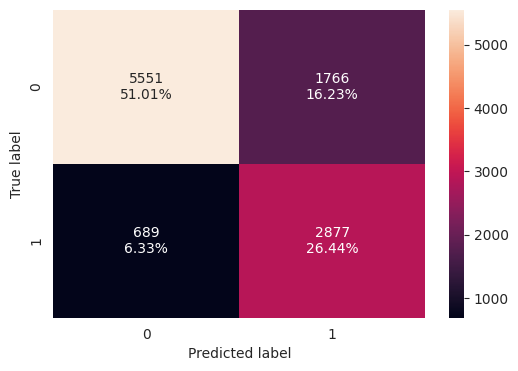

In [ ]:
#Threshold 0.296 test data confusion matrix
confusion_matrix_statsmodels(lg7, X_test7, y_test, threshold=0.296)

In [ ]:
# checking model performance for this model
final_log_reg_model_test_perf_threshold_auc_roc = model_performance_classification_statsmodels(
    lg7, X_test7, y_test, threshold=0.296
)
print("Test performance:")
log_reg_model_test_perf_threshold_auc_roc

Test performance:


,Accuracy,Recall,Precision,F1
0,0.77460,0.80679,0.61991,0.70111


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        log_reg_model_test_perf.T,
        log_reg_model_test_perf_threshold_auc_roc.T,
        log_reg_model_test_perf_threshold_curve.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression-default Threshold (0.5)",
    "Logistic Regression-0.296 Threshold",
    "Logistic Regression-0.435 Threshold",
]

print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Logistic Regression-default Threshold (0.5),Logistic Regression-0.296 Threshold,Logistic Regression-0.435 Threshold
Accuracy,0.80088,0.77460,0.79491
Recall,0.63180,0.80679,0.68648
Precision,0.72514,0.61991,0.68725
F1,0.67526,0.70111,0.68687


Looking at the metrics table, with the objective of maximizing the recall score, the model AUC_ROC model with threshold of 0.296 gives the best score

In [ ]:
# training vs testing performance comparison of threshold of 0.296

Final_model_train_test_comp_df = pd.concat(
    [
        final_log_reg_model_train_perf_threshold_auc_roc.T,
        final_log_reg_model_test_perf_threshold_auc_roc.T,
    ],
    axis=1,
)
Final_model_train_test_comp_df.columns = [
    "Logistic Regression-Training Data",
    "Logistic Regression-Testing Data",
]

print("Training / Testing Performance comparison:")
Final_model_train_test_comp_df

Training / Testing Performance comparison:


,Logistic Regression-Training Data,Logistic Regression-Testing Data
Accuracy,0.77922,0.77442
Recall,0.82029,0.80679
Precision,0.62405,0.61964
F1,0.70884,0.70094


As shown earlier, all metrics are within accepotable range with highest priority given to recall to minimize false negatives being predicted.

This should minimize the amount of predicted no cancellations that turn out to be cancels and therefore maximize earnings potential.

### Final Model AUC Plot

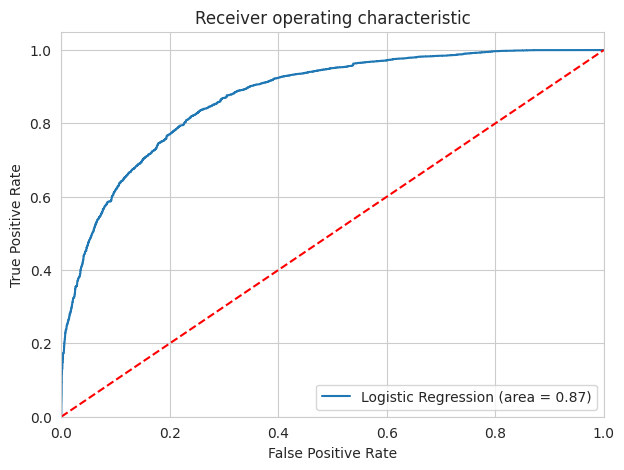

In [ ]:
#Check area under curve graph to measure performance and optimal threshold value
logit_roc_auc_train = roc_auc_score(y_train, lg7.predict(X_train7))
fpr, tpr, thresholds = roc_curve(y_train, lg7.predict(X_train7))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

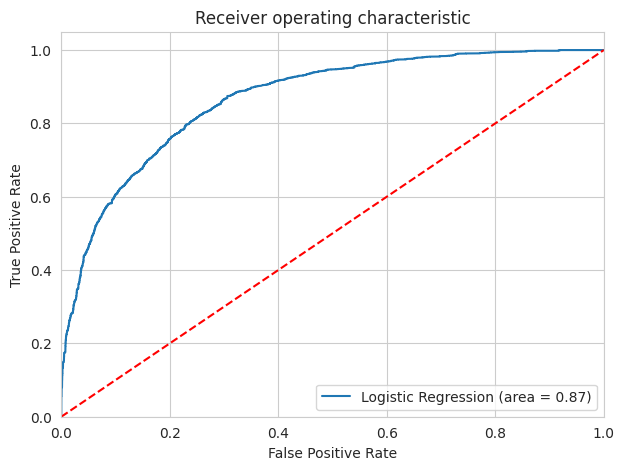

In [ ]:
#Threshold 0.296 test data area under curve
logit_roc_auc_train = roc_auc_score(y_test, lg7.predict(X_test7))
fpr, tpr, thresholds = roc_curve(y_test, lg7.predict(X_test7))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

Area under curve for testing and training data conssiten with a value of 0.87.

### Odds and Insights

In [ ]:
# converting coefficients to odds
odds = np.exp(lg_Final.params)

# finding the percentage change
perc_change_odds = (np.exp(lg_Final.params) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train7.columns).T

,const,no_of_weekend_nights,no_of_week_nights,lead_time,no_of_previous_cancellations,avg_price_per_room,no_of_special_requests,required_car_parking_space_Yes,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,arrival_year_2018,arrival_month_2,arrival_month_3,arrival_month_4,arrival_month_5,arrival_month_6,arrival_month_7,arrival_month_8,arrival_month_9,arrival_month_10,arrival_month_11,arrival_month_12,arrival_date_2,arrival_date_3,arrival_date_5,arrival_date_7,arrival_date_9,arrival_date_10,arrival_date_13,arrival_date_14,arrival_date_21,arrival_date_23,arrival_date_24,arrival_date_29,market_segment_type_Online,repeated_guest_Yes
Odds,0.00071,1.15938,1.04753,1.01585,1.44807,1.01884,0.21500,0.20528,0.69357,0.75004,0.54752,0.51720,0.28125,1.65915,22.31704,15.09019,11.48055,8.96016,10.68597,10.61531,9.56615,8.94217,12.44585,15.81698,2.56748,0.57557,0.74183,0.78200,0.69457,0.65714,0.76282,0.54714,0.64585,0.63472,0.76016,0.74321,0.66200,5.63841,0.06181
Change_odd%,-99.92937,15.93795,4.75311,1.58547,44.80733,1.88367,-78.49995,-79.47185,-30.64348,-24.99631,-45.24750,-48.27969,-71.87533,65.91542,2131.70397,1409.01858,1048.05454,796.01564,968.59678,961.53060,856.61500,794.21663,1144.58468,1481.69782,156.74760,-42.44337,-25.81672,-21.79964,-30.54335,-34.28571,-23.71845,-45.28648,-35.41512,-36.52783,-23.98386,-25.67891,-33.80004,463.84105,-93.81898


- For every 1 unit increase for number of weekend nights the liklihood of a cancellation goes up 1.16 times or by 15.94%.

- For every 1 unit increase for number of week nights the liklihood of a cancellation goes up 1.05 times or by 4.75%.

- For every 1 unit increase for lead time the liklihood of a cancellation goes up 1.02 times or by 1.59%.

- For every 1 unit increase for number of previous cancellations the liklihood of a cancellation goes up 1.45 times or by 44.81%.

- For every 1 unit increase for average price per room the liklihood of a cancellation goes up 1.02 times or by 1.88%.

- For every 1 unit increase for both number of special requests and saying yes to a parking space, the liklihood of a cancellation goes down ~0.2 times or by -78% - -79%.

- Guests booking rooms 2, 4, 5, 6, and 7 are much less likely to cancel their booking with percent decreases of 30% to 71%.

- Repeat guests are 93.82% less likely to cancel their bookings



## Building a Decision Tree model

### Functions

In [ ]:
## Function to create confusion matrix
def make_confusion_matrix(model,y_actual,labels=[1, 0]):
    '''
    model : classifier to predict values of X
    y_actual : ground truth

    '''
    y_predict = model.predict(X_test)
    cm=metrics.confusion_matrix( y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(cm, index = [i for i in ["Actual - No","Actual - Yes"]],
                  columns = [i for i in ['Predicted - No','Predicted - Yes']])
    group_counts = ["{0:0.0f}".format(value) for value in
                cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in
                         cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in
              zip(group_counts,group_percentages)]
    labels = np.asarray(labels).reshape(2,2)
    plt.figure(figsize = (10,7))
    sns.heatmap(df_cm, annot=labels,fmt='')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
##  Function to calculate recall score
def get_recall_score(model):
    '''
    model : classifier to predict values of X

    '''
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    print("Recall on training set : ",metrics.recall_score(y_train,pred_train))
    print("Recall on test set : ",metrics.recall_score(y_test,pred_test))

### Initial Model

In [ ]:
X = df.drop(["booking_status","Booking_ID"], axis=1)
y = df["booking_status"]

# creating dummies
X = pd.get_dummies(X, drop_first=True)
X = X.astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.30, random_state=1)

In [ ]:
dTree = DecisionTreeClassifier(criterion = 'gini', random_state=1)
dTree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
print("Accuracy on training set : ",dTree.score(X_train, y_train))
print("Accuracy on test set : ",dTree.score(X_test, y_test))

Accuracy on training set :  0.994210775047259
Accuracy on test set :  0.86731599742718


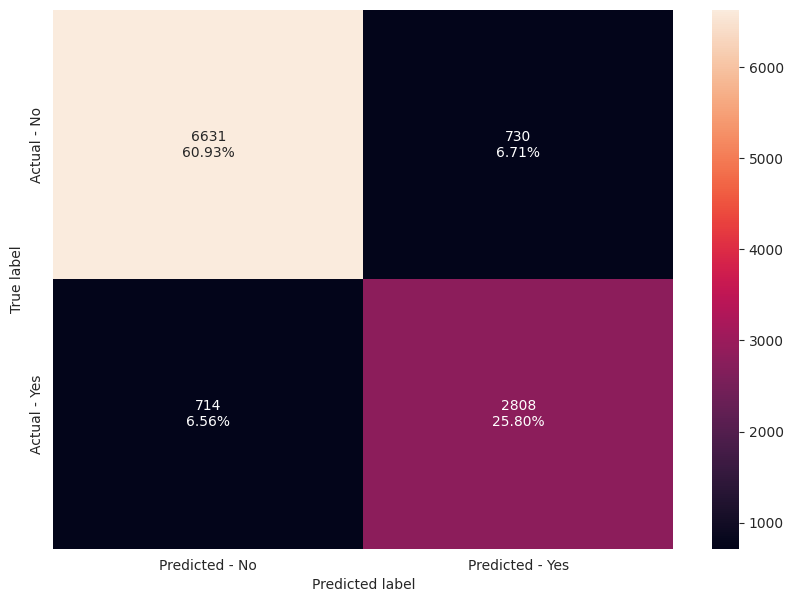

In [ ]:
make_confusion_matrix(dTree,y_test)

In [ ]:
# Recall on train and test
get_recall_score(dTree)

Recall on training set :  0.9866076766710511
Recall on test set :  0.797274275979557


In [ ]:
#Check Model performance for training data
model_performance_classification_statsmodels(dTree, X_train, y_train)

,Accuracy,Recall,Precision,F1
0,0.99421,0.98661,0.99578,0.99117


In [ ]:
#Check model performance for testing data
model_performance_classification_statsmodels(dTree, X_test, y_test)

,Accuracy,Recall,Precision,F1
0,0.86732,0.79727,0.79367,0.79547


In [ ]:
feature_names = list(X.columns)
print(feature_names)

['no_of_adults', 'no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'lead_time', 'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled', 'avg_price_per_room', 'no_of_special_requests', 'required_car_parking_space_Yes', 'room_type_reserved_Room_Type 2', 'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4', 'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6', 'room_type_reserved_Room_Type 7', 'arrival_year_2018', 'arrival_month_2', 'arrival_month_3', 'arrival_month_4', 'arrival_month_5', 'arrival_month_6', 'arrival_month_7', 'arrival_month_8', 'arrival_month_9', 'arrival_month_10', 'arrival_month_11', 'arrival_month_12', 'arrival_date_2', 'arrival_date_3', 'arrival_date_4', 'arrival_date_5', 'arrival_date_6', 'arrival_date_7', 'arrival_date_8', 'arrival_date_9', 'arrival_date_10', 'arrival_date_11', 'arrival_date_12', 'arrival_date_13', 'arrival_date_14', 'arrival_date_15', 'arrival_date_16', 'arrival_date_17',

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(dTree,feature_names=feature_names,show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- avg_price_per_room <= 201.50
|   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |--- arrival_month_5 <= 0.50
|   |   |   |   |   |   |   |--- lead_time <= 26.50
|   |   |   |   |   |   |   |   |--- arrival_date_18 <= 0.50
|   |   |   |   |   |   |   |   |   |--- room_type_reserved_Room_Type 4 <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- arrival_date_17 <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 20
|   |   |   |   |   |   |   |   |   |   |--- arrival_date_17 >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |   |   |   |   |   |--- room_type_reserved_Room_Type 4 >  0.50
|   |   |   |   |   |   |   |   |   |   |--- arrival_date_14 <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated 

In [ ]:
dTree.get_depth()

43

In [ ]:
dTree.feature_importances_

array([3.06106230e-02, 4.71690920e-03, 2.90726145e-02, 3.65383569e-02,
       1.24203270e-02, 3.38485823e-01, 1.57219564e-04, 7.46042562e-04,
       1.62748556e-01, 6.72162282e-02, 6.86868286e-03, 2.27547328e-03,
       1.29576563e-05, 6.14399374e-03, 1.40971600e-03, 3.12135544e-04,
       2.22636095e-04, 1.13953901e-02, 3.29151219e-03, 6.73917789e-03,
       1.00250550e-02, 3.94249266e-03, 3.10001771e-03, 7.89468870e-03,
       5.33561418e-03, 4.40418216e-03, 7.24758624e-03, 6.35347499e-03,
       2.05560806e-02, 4.46013546e-03, 2.42221230e-03, 4.28397347e-03,
       6.99731619e-03, 2.56805164e-03, 2.93387891e-03, 2.88735463e-03,
       3.70277217e-03, 2.49777937e-03, 4.74828283e-03, 5.35220922e-03,
       3.87551629e-03, 3.12955614e-03, 3.88643558e-03, 4.00834618e-03,
       6.03832583e-03, 4.01021446e-03, 3.22762405e-03, 2.74162441e-03,
       5.06049362e-03, 4.58591958e-03, 2.99395996e-03, 4.04060410e-03,
       4.07452128e-03, 3.51165462e-03, 4.28209066e-03, 6.84554979e-03,
      

In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(dTree.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                         Imp
lead_time                            0.33849
avg_price_per_room                   0.16275
market_segment_type_Online           0.08975
no_of_special_requests               0.06722
no_of_week_nights                    0.03654
no_of_adults                         0.03061
no_of_weekend_nights                 0.02907
arrival_month_12                     0.02056
type_of_meal_plan                    0.01242
arrival_year_2018                    0.01140
arrival_month_4                      0.01003
arrival_month_7                      0.00789
arrival_month_10                     0.00725
arrival_date_5                       0.00700
required_car_parking_space_Yes       0.00687
arrival_date_28                      0.00685
arrival_month_3                      0.00674
arrival_month_11                     0.00635
room_type_reserved_Room_Type 4       0.00614
arrival_date_17                      0.00604
arrival_date_12                      0.00535
arrival_mo

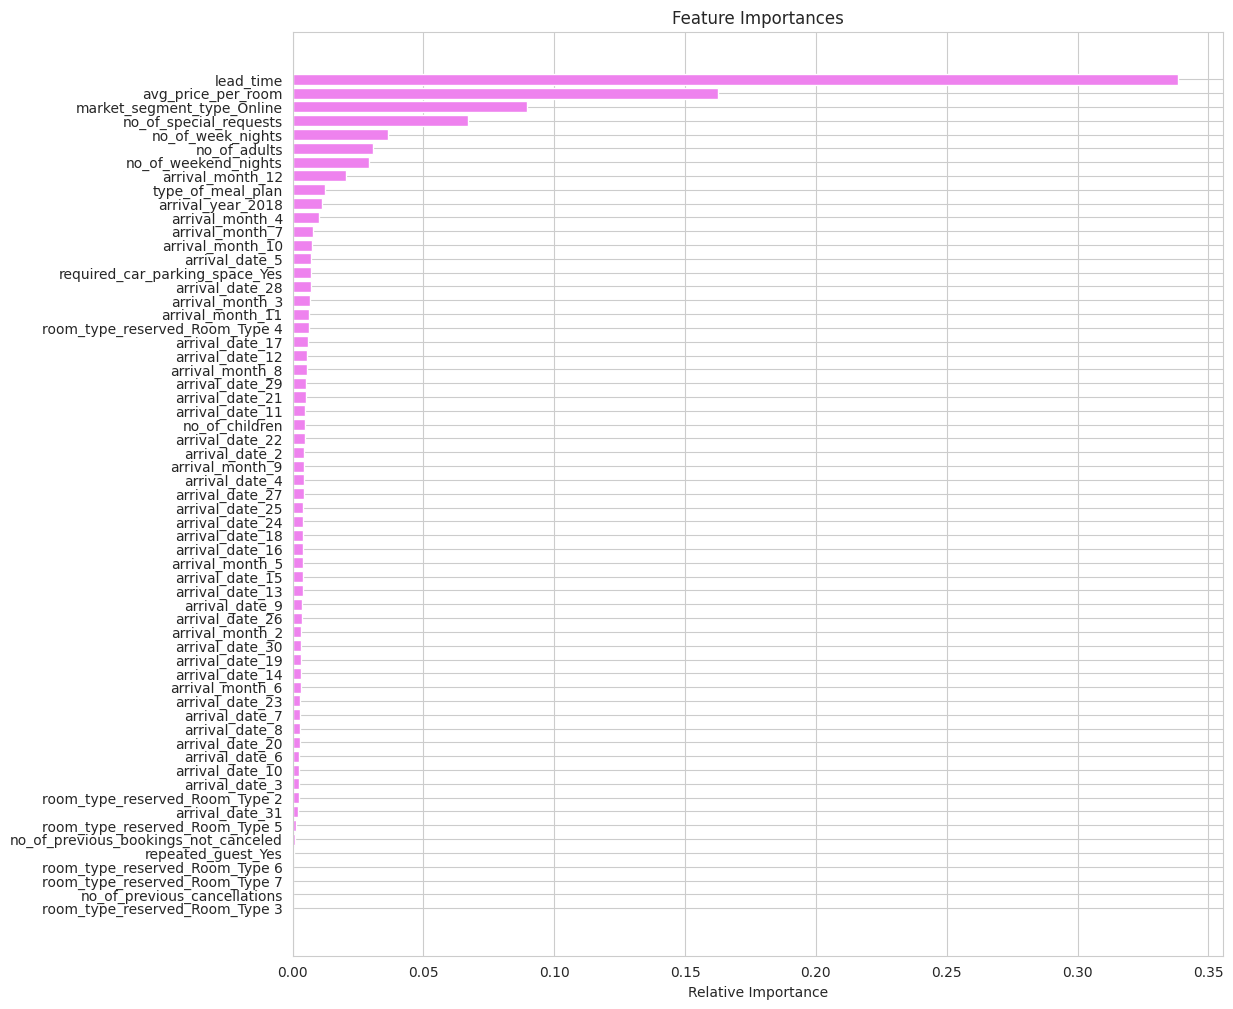

In [ ]:
importances = dTree.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

Given the accuracy is almost 1 and training being 0.79 for the training dataset and the complexity of the decision tree being 43 layers deep, this implies that the model is overfit.

## Do we need to prune the tree?

Yes the model can benefit from pruning.

### Grid Search

In [ ]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
## add from article
parameters = {'max_depth': np.arange(1,10),
              'min_samples_leaf': [1, 2, 5, 7, 10,15,20],
              'max_leaf_nodes' : [2, 3, 5, 10],
              'min_impurity_decrease': [0.001,0.01,0.1]
             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=np.int64(3), max_leaf_nodes=5,
                       min_impurity_decrease=0.001, random_state=1)

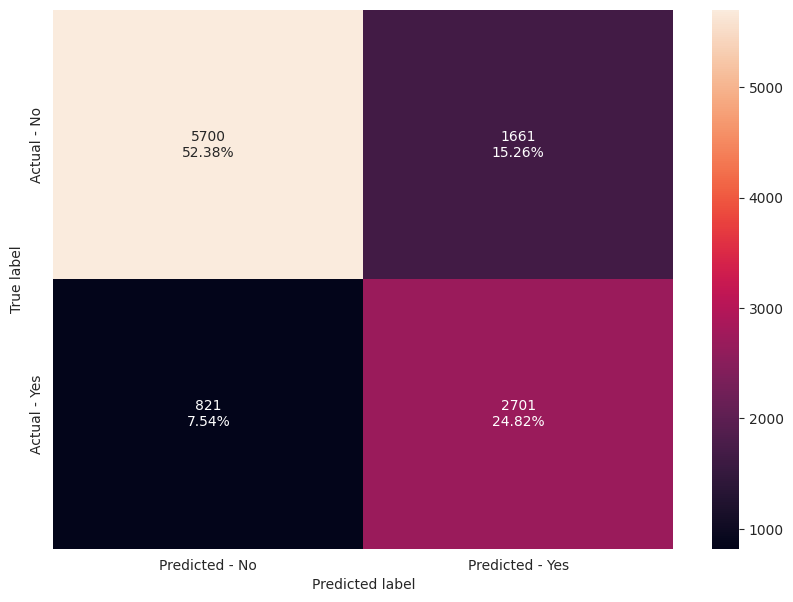

In [ ]:
make_confusion_matrix(estimator,y_test)

In [ ]:
print("Accuracy on training set : ",estimator.score(X_train, y_train))
print("Accuracy on test set : ",estimator.score(X_test, y_test))
# Recall on train and test
get_recall_score(estimator)

Accuracy on training set :  0.7694943289224953
Accuracy on test set :  0.7719378847744188
Recall on training set :  0.7631232811192156
Recall on test set :  0.7668938103350369


In [ ]:
model_performance_classification_statsmodels(estimator, X_train, y_train)

,Accuracy,Recall,Precision,F1
0,0.76949,0.76312,0.62239,0.68561


In [ ]:
model_performance_classification_statsmodels(estimator, X_test, y_test)

,Accuracy,Recall,Precision,F1
0,0.77194,0.76689,0.61921,0.68519


Using Grid search, we have achieved a much more reasonable model with Accuracy for training and testing data at around 77% and the recall at 76%.


The training and testing data being almost the same gives good indcation that the model is not over-fitted.

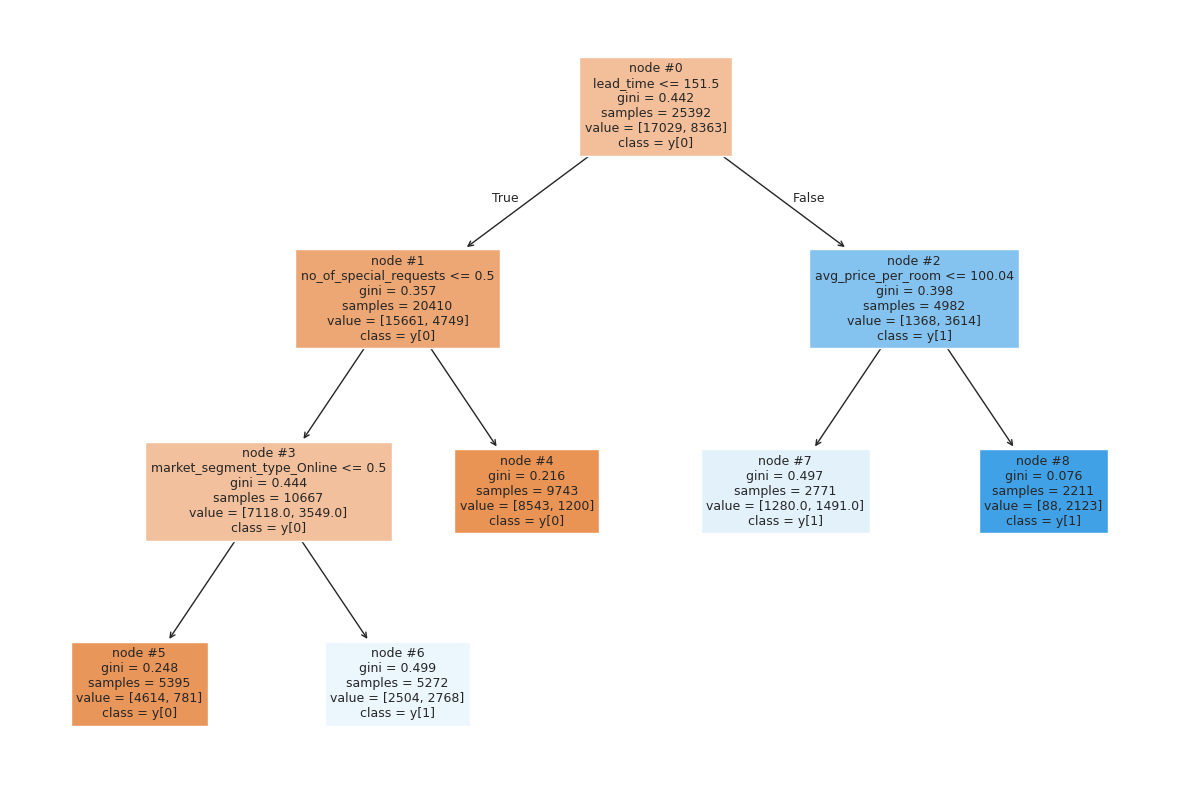

In [ ]:
plt.figure(figsize=(15,10))

tree.plot_tree(estimator,feature_names=feature_names,filled=True,fontsize=9,node_ids=True,class_names=True)
plt.show()

In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
#(normalized) total reduction of the 'criterion' brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(estimator.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

#Here we will see that importance of features has increased

                                         Imp
lead_time                            0.53997
market_segment_type_Online           0.21415
no_of_special_requests               0.12418
avg_price_per_room                   0.12170
no_of_children                       0.00000
type_of_meal_plan                    0.00000
no_of_week_nights                    0.00000
no_of_weekend_nights                 0.00000
no_of_previous_cancellations         0.00000
no_of_previous_bookings_not_canceled 0.00000
required_car_parking_space_Yes       0.00000
room_type_reserved_Room_Type 2       0.00000
no_of_adults                         0.00000
room_type_reserved_Room_Type 4       0.00000
room_type_reserved_Room_Type 5       0.00000
room_type_reserved_Room_Type 6       0.00000
room_type_reserved_Room_Type 7       0.00000
arrival_year_2018                    0.00000
arrival_month_2                      0.00000
arrival_month_3                      0.00000
arrival_month_4                      0.00000
arrival_mo

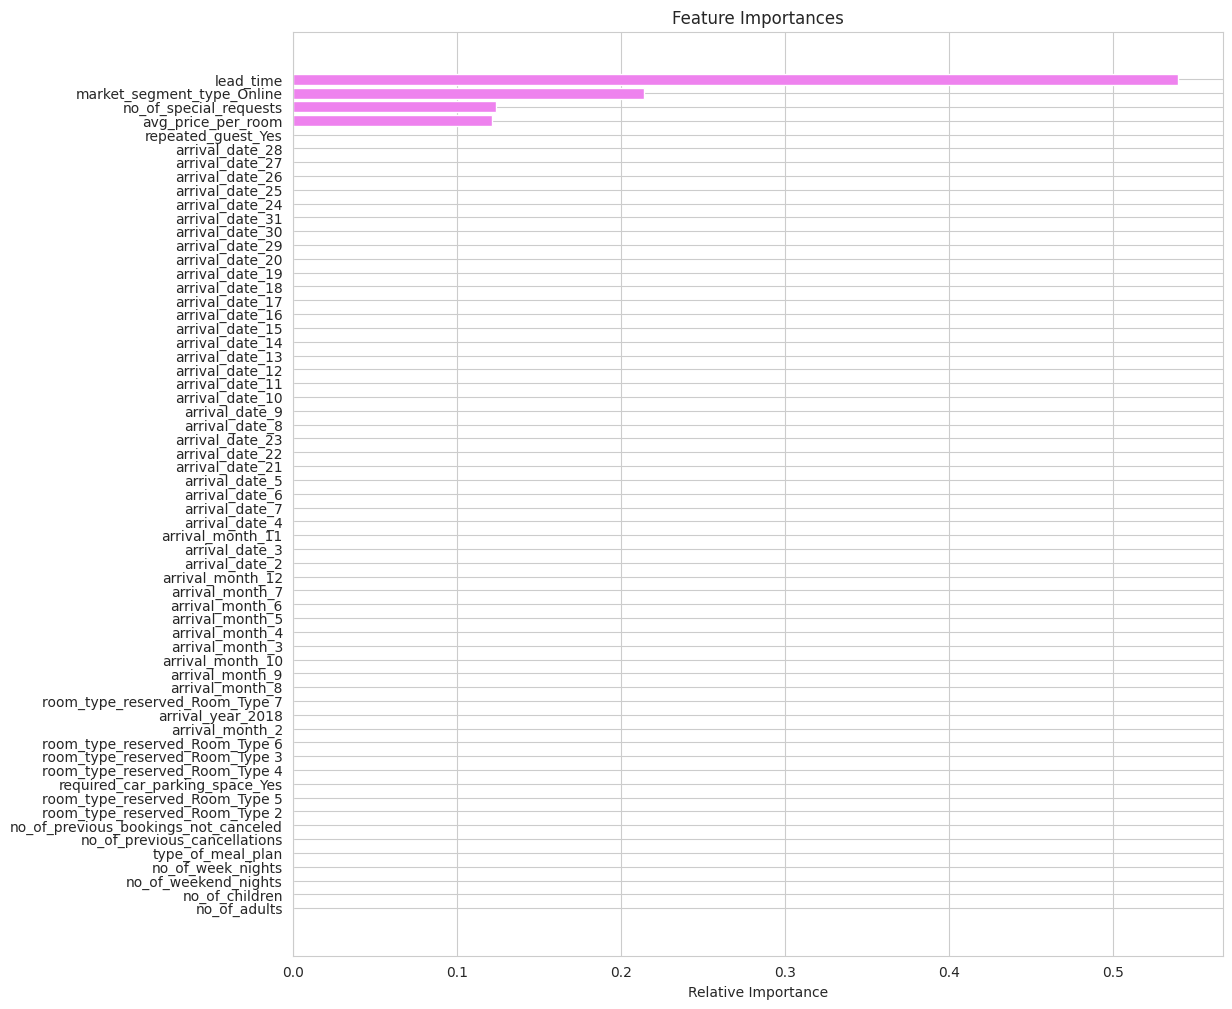

In [ ]:
importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

Lead time, market segment type online, number of special requests, average price per roomed guest are the main factors for the decision tree.

### Cost Complexity Pruning

In [ ]:
#Create model for post pruning
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.00000,0.00838
1,0.00000,0.00838
2,0.00000,0.00838
3,0.00000,0.00838
4,0.00000,0.00838
...,...,...
1738,0.00890,0.32806
1739,0.00980,0.33786
1740,0.01272,0.35058
1741,0.03412,0.41882


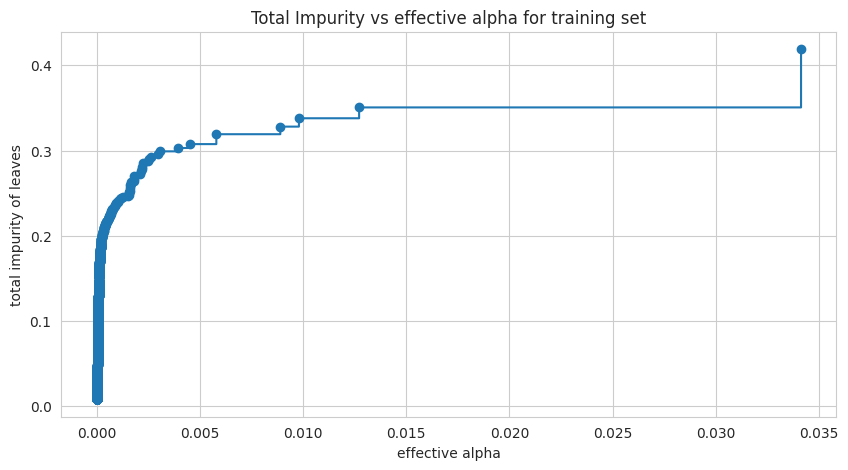

In [ ]:
#Plot impurity of leaves vs effective alpha
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [ ]:
#Create decision tree using cost complexity pruning alpha
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
      clfs[-1].tree_.node_count, ccp_alphas[-1]))

Number of nodes in the last tree is: 1 with ccp_alpha: 0.08117914389137021


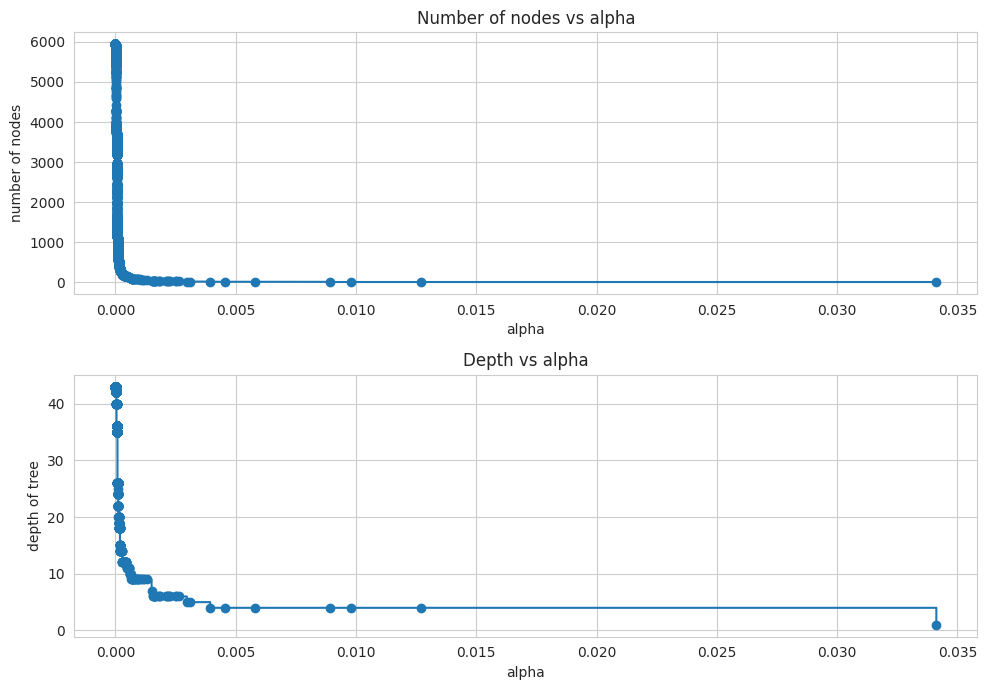

In [ ]:
#Plot Number of nodes and Depth of tree with alpha
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1,figsize=(10,7))
ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker='o', drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

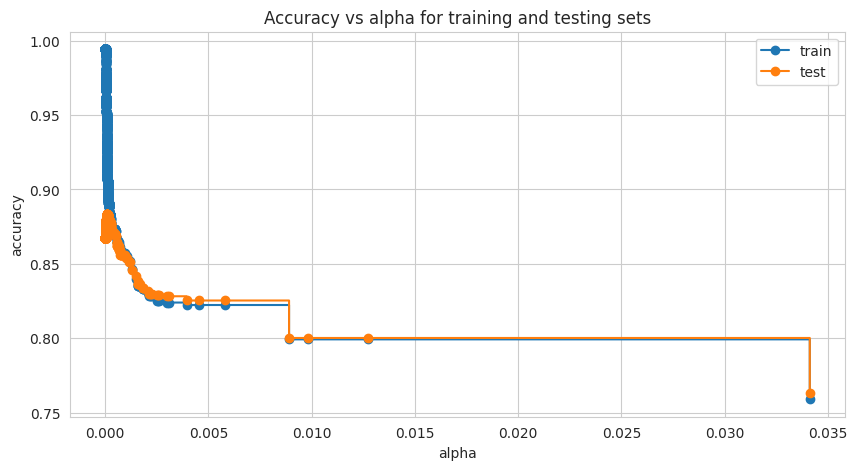

In [ ]:
#Plot training vs testing data Accuracy score
fig, ax = plt.subplots(figsize=(10,5))
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
#Check accuracy score
index_best_model = np.argmax(test_scores)
best_model = clfs[index_best_model]
print(best_model)
print('Training accuracy of best model: ',best_model.score(X_train, y_train))
print('Test accuracy of best model: ',best_model.score(X_test, y_test))

DecisionTreeClassifier(ccp_alpha=np.float64(0.00010731975339582428),
                       random_state=1)
Training accuracy of best model:  0.9070179584120983
Test accuracy of best model:  0.8836717816778462


In [ ]:
#Check training scores for all metrics
model_performance_classification_statsmodels(best_model, X_train, y_train)

,Accuracy,Recall,Precision,F1
0,0.95274,0.90817,0.94618,0.92678


In [ ]:
#Check testing scores for all metrics
model_performance_classification_statsmodels(best_model, X_test, y_test)

,Accuracy,Recall,Precision,F1
0,0.87880,0.80068,0.82048,0.81046


In [ ]:
#Calculate recall score for training data
recall_train=[]
for clf in clfs:
    pred_train3=clf.predict(X_train)
    values_train=metrics.recall_score(y_train,pred_train3)
    recall_train.append(values_train)

In [ ]:
#Calculate recall score for testing data
recall_test=[]
for clf in clfs:
    pred_test3=clf.predict(X_test)
    values_test=metrics.recall_score(y_test,pred_test3)
    recall_test.append(values_test)

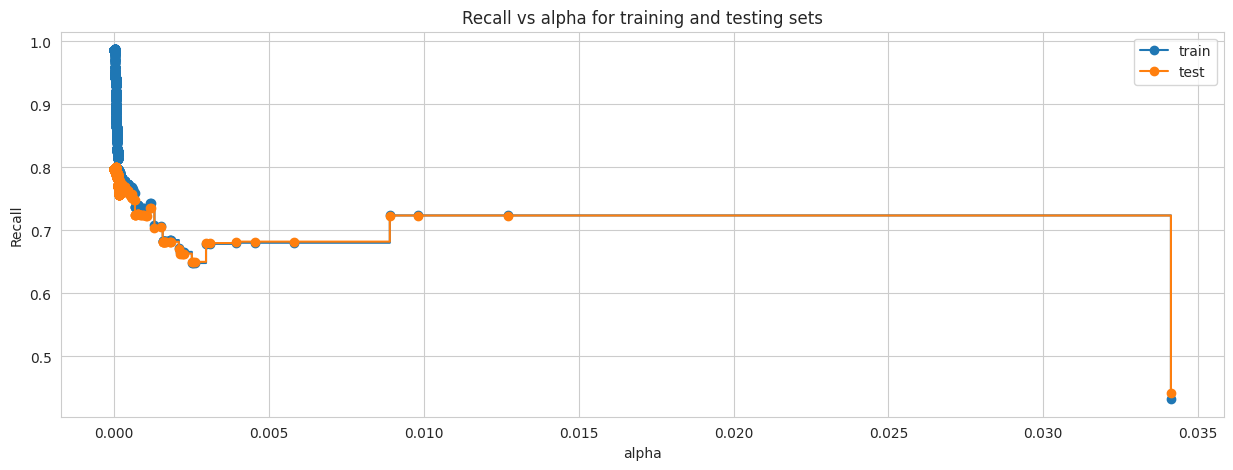

In [ ]:
#Plot recall for training vs testing data vs alpha score
fig, ax = plt.subplots(figsize=(15,5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker='o', label="train",
        drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker='o', label="test",
        drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=np.float64(5.925048141016728e-05),
                       random_state=1)


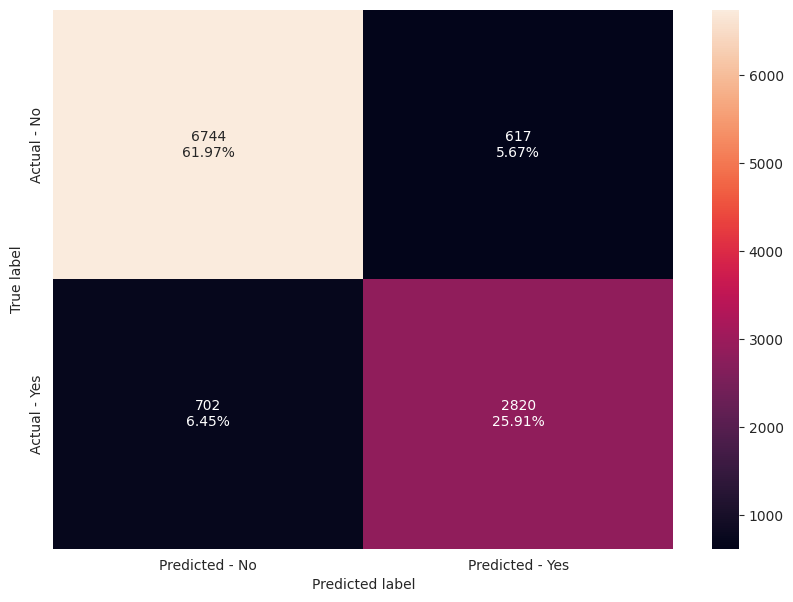

In [ ]:
#Check confusion matrix of cost complexity pruning
make_confusion_matrix(best_model,y_test)

In [ ]:
#Check training scores for all metrics
model_performance_classification_statsmodels(best_model, X_train, y_train)

,Accuracy,Recall,Precision,F1
0,0.95274,0.90817,0.94618,0.92678


In [ ]:
#Check testing scores for all metrics
model_performance_classification_statsmodels(best_model, X_test, y_test)

,Accuracy,Recall,Precision,F1
0,0.87880,0.80068,0.82048,0.81046


In [ ]:
#Check max depth of the cost complexity pruning tree
best_model.get_depth()

36

In [ ]:
# Text report showing the rules of a decision tree -

print(tree.export_text(best_model,feature_names=feature_names,show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type_Online <= 0.50
|   |   |   |--- lead_time <= 90.50
|   |   |   |   |--- avg_price_per_room <= 201.50
|   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |--- arrival_month_5 <= 0.50
|   |   |   |   |   |   |   |--- lead_time <= 26.50
|   |   |   |   |   |   |   |   |--- arrival_date_18 <= 0.50
|   |   |   |   |   |   |   |   |   |--- room_type_reserved_Room_Type 4 <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- arrival_date_17 <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |   |   |   |   |   |--- arrival_date_17 >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |   |   |   |   |   |--- room_type_reserved_Room_Type 4 >  0.50
|   |   |   |   |   |   |   |   |   |   |--- arrival_date_14 <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated b

In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
#(normalized) total reduction of the 'criterion' brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(best_model.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

                                         Imp
lead_time                            0.36197
avg_price_per_room                   0.16124
market_segment_type_Online           0.10631
no_of_special_requests               0.07975
no_of_adults                         0.03105
no_of_week_nights                    0.02871
no_of_weekend_nights                 0.02562
arrival_month_12                     0.02348
arrival_year_2018                    0.01285
arrival_month_4                      0.01012
type_of_meal_plan                    0.00984
required_car_parking_space_Yes       0.00749
arrival_date_28                      0.00729
arrival_month_10                     0.00715
arrival_month_7                      0.00678
arrival_date_5                       0.00657
arrival_month_11                     0.00593
arrival_month_3                      0.00574
arrival_date_29                      0.00506
room_type_reserved_Room_Type 4       0.00487
arrival_date_17                      0.00485
arrival_da

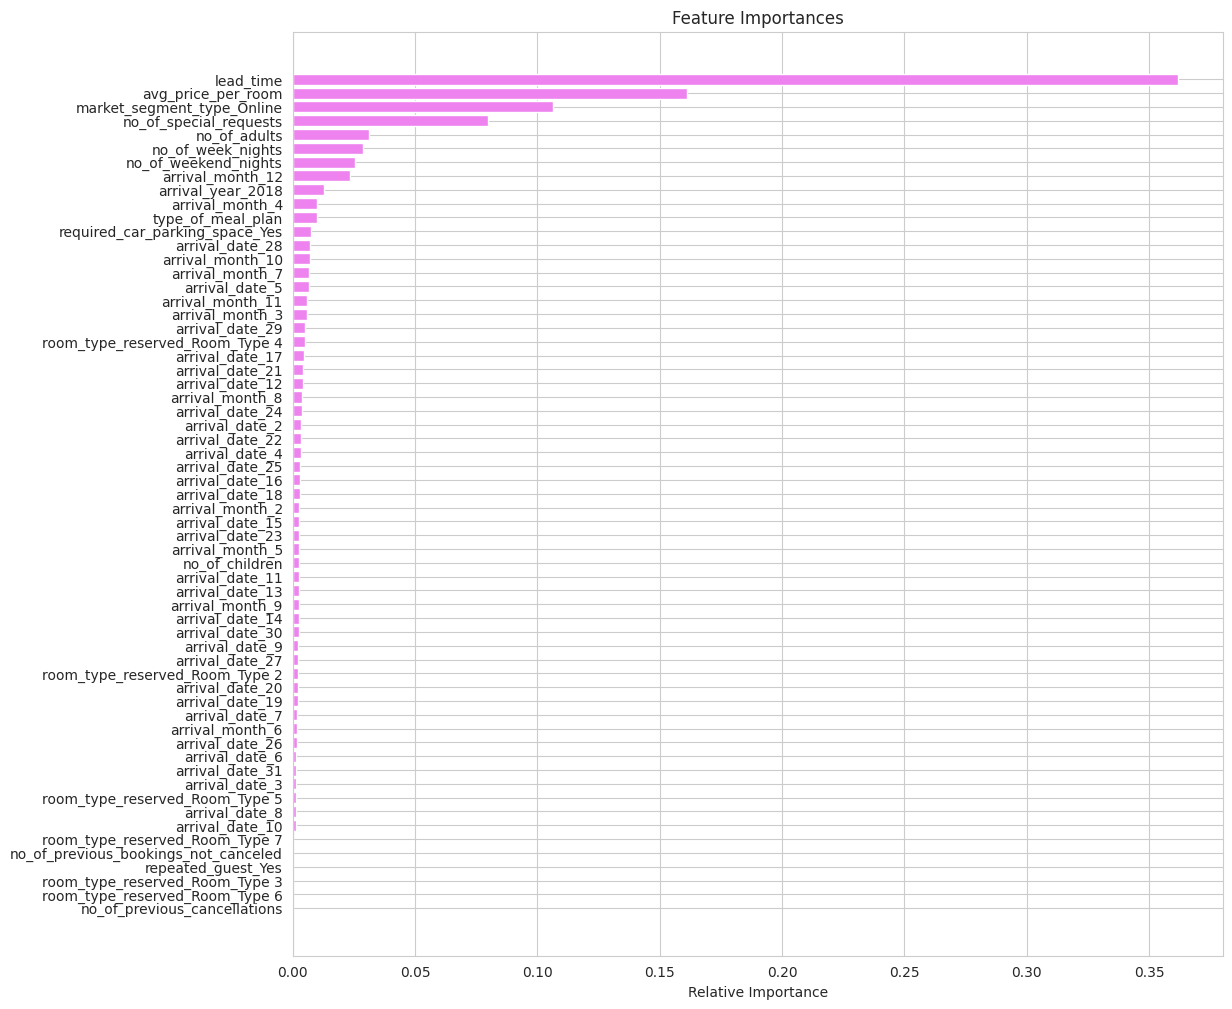

In [ ]:
importances = best_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

Using cost complexity pruning, the recall score has improved by about 4% for the testing data over the pre-pruning method.

The complexity of the tree, however, has increased with a max depth of 36 and a 10% difference between the training and testing recall score which is on the high side.

## Model Performance Comparison and Conclusions

In [ ]:
comparison_frame = pd.DataFrame({
    'Model':['Logistic Regression Model','Initial decision tree model','Decision treee with hyperparameter tuning',
                                         'Decision tree with post-pruning'],
    'Train_Accuracy':[0.78,0.99,0.77,0.95], 'Test_Accuracy':[0.77,0.87,0.77,0.88],
    'Train_Recall':[0.82,0.99,0.76,0.91], 'Test_Recall':[0.81,0.80,0.77,0.80],
    'Train_Precision':[0.62,0.99,0.95,0.94], 'Test_Precision':[0.61,0.79,0.82,0.82],
    'Train_F1':[0.71,0.99,0.93,0.93], 'Test_F1':[0.7,0.79,0.81,0.81]})
comparison_frame

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1,Test_F1
0,Logistic Regression Model,0.78000,0.77000,0.82000,0.81000,0.62000,0.61000,0.71000,0.70000
1,Initial decision tree model,0.99000,0.87000,0.99000,0.80000,0.99000,0.79000,0.99000,0.79000
2,Decision treee with hyperparameter tuning,0.77000,0.77000,0.76000,0.77000,0.95000,0.82000,0.93000,0.81000
3,Decision tree with post-pruning,0.95000,0.88000,0.91000,0.80000,0.94000,0.82000,0.93000,0.81000


Looking at the different models generated:

- Logistic Rgression: Logistic regression provides consistent scores for all metrics across the board with the recall score being maximized at 82% and 81% for the training and testing data.

- Initial Decision Tree Model: The initial data tree is overfitted with all training score being 99% and the testing scores being much lower.

- Decision tree with hyper parameter tuning: The Grid Search method has good accuracy and recall matches for training and testing but larger descrepencies for the Precision and F1 scores. Recall which is our metric we want to maximize has 76% and 77% for training and testing

- Decision tree with post pruning: The post pruning decision tree has good scores across the board but the descrepency between training and testing for all metrics is large (anywhere from 7% to 12%). This could be an indication of the model overfitting.

Given the above, the logistic regression model provides the best result where the training and testing scores for all metrics are very close to one another, and the recall score is maximized at 82% and 81%. Accuracy is also good at 78% and 77%.

## Actionable Insights and Recommendations

- What profitable policies for cancellations and refunds can the hotel adopt?

1. Lead time for the logistic regression model showed that the farther out a room was booked, the more likely a cancellation would occur. A good policy to implement may be to limit the amount of lead time a guest can book a room so they are less likely to cancel.

2. The more weekend and week nights booked the higher the chance the guest will cancel (weekends being higher than weeknights). For extended stays, a deposit can be required with full refund given with lots of lead time left for stay but no refund when lead time to stay reaches a certain amount.

For shorter stays, no deposit is required and customers can cancel for a full refund with large amount of lead time and no refund as the stay date gets close.

3. The liklihood of cancellation increases the larger the average price of the room. The cancellation fee can be based on a percentage of the average room cost for that stay to discourage cancellations for more expensive rooms.

4. If there is a history of previous cancellations, require a deposit for the room upfront and base the refund percentage based on number of previous cancellations.

- What other recommedations would you suggest to the hotel?

1. Since repeat guests are unlikely to cancel, incentives can be provided for first time customers such as room rate reduction, or a free room upgrade to one of the better room number choices. The same incentives can be provided for repeat guests with a rewards program.

2. A special request(s) can reduce the chance of a cancellation occuring. For booking, encourage the guest to make a special request by giving them special request options and/or a blank space to write in their own request.

3. If a guest requires a parking space they are less likely to cancel. Offering free parking for all guests can encourage guests to drive to the hotel to get a parking spot.